In [1]:
# import libraries
import math

import numpy
import numpy as np
import matplotlib.pyplot as plt
import sklearn.preprocessing
import itertools
import torch
import random
import time

# import Koopman Libraries
from core.koopman_core_linear import KoopDNN_linear, KoopmanNet_linear, KoopmanNetCtrl_linear
# from core.koopman_linear_time_delay import KoopDNN, KoopmanNet, KoopmanNetCtrl
from sklearn import preprocessing
from core.util import fit_standardizer
from models.koop_model import model_matricies,lift

# Import Adaptive Koopman
from core.adapt_net_linear import AdaptNet_linear
import scipy.io
import importlib
import dynamics.caca as caca
importlib.reload(caca)

# from dynamics.sync_pendulum import sync_pendulum_data_gen_multi, FK_solver

# from dynamics.sync_pendulum import FK_solver, single_vehicle_data_gen_multi
from dynamics.caca import FK_solver, single_vehicle_data_gen_multi

## System Generation

In [2]:
"""Choose the type of Koopman representation"""
linear = True

## Data Generation

In [3]:
# define system pars
sys_pars = {}

num_states = 5
num_inputs = 2
dt = 0.02

sys_pars['num_states'] = num_states
sys_pars['num_inputs'] = num_inputs
sys_pars['dt'] = dt

# vehicle parameters
sys_pars['m'] = 1500.0
sys_pars['Iz'] = 2250.0
sys_pars['lf'] = 1.2
sys_pars['lr'] = 1.6
sys_pars['Cf'] = 80000.0
sys_pars['Cr'] = 80000.0
sys_pars['vx_ref'] = 15.0
sys_pars['curvature_ref'] = 0.0

# # input generation
# sys_pars['U_type'] = 'random'      # 'random' or 'sinusoidal'
# sys_pars['delta_max'] = 0.08       # rad
# sys_pars['ax_max'] = 2.0           # m/s^2

# input generation
sys_pars['U_type'] = 'sinusoidal'
# sys_pars['delta_max'] = 0.03
sys_pars['delta_max'] = 0.05

sys_pars['ax_max'] = 0.6

# uncertainty setting
sys_pars['uncertainty'] = 'NA'
sys_pars['amp'] = 0.0
sys_pars['freq'] = 1.0

In [4]:
# # define system pars
# sys_pars = {}
# N = 5
# num_states = 2*N
# num_inputs = 1
# dt = 0.01
# sys_pars['num_states'] = num_states
# sys_pars['num_inputs'] = num_inputs
#
# sys_pars['N'] = N  #number of pendulums
# sys_pars['f_origin'] = 0
# sys_pars['m'] = 0.017
# sys_pars['l'] = 0.1
# sys_pars['gamma'] = 3.1956332e-4
# sys_pars['b'] = 6.819e-4
# sys_pars['k'] = 0.079
# sys_pars['J'] = sys_pars['m']*sys_pars['l']**2
# sys_pars['g'] = 9.81
# sys_pars['dt'] = dt
#
# adj_mat = np.diag(np.ones((N-1)), 1) + np.diag(np.ones((N-1)), -1)
# L = np.diag(sum(adj_mat)) - adj_mat
# sys_pars['L'] = L
# sys_pars['d'] = np.hstack((np.array([1]),np.zeros((N-1)))).reshape((N,-1))
# sys_pars['F_type'] = 'sinusoidal' #type of inputs used to generate data
# sys_pars['F_max'] = 0.1 #maximum amplitude of torque to generate dataset
#
# sys_pars['uncertainty'] = 'NA'
# sys_pars['amp_frac'] = 0


In [5]:
# # # system pars
# sys_pars_new = {} #system parameters for the uncertain system
# percent_change = 40 #percentage change in the parameters of the system
# 
# sys_pars_new['num_states'] = num_states
# sys_pars_new['num_inputs'] = num_inputs
# 
# sys_pars_new['N'] = N
# sys_pars_new['f_origin'] = sys_pars['f_origin']
# sys_pars_new['m'] = sys_pars['m'] * (1 + random.choice([-1,1])*percent_change/100)
# sys_pars_new['l'] = sys_pars['l'] * (1 + random.choice([-1,1])*percent_change/100)
# sys_pars_new['gamma'] = sys_pars['gamma'] * (1 + random.choice([-1,1])*percent_change/100)
# sys_pars_new['b'] = sys_pars['b'] * (1 + random.choice([-1,1])*percent_change/100)
# sys_pars_new['k'] = sys_pars['k'] * (1 + random.choice([-1,1])*percent_change/100)
# sys_pars_new['J'] = sys_pars_new['m']*sys_pars_new['l']**2
# sys_pars_new['g'] = sys_pars['g']
# sys_pars_new['F_max'] = sys_pars['F_max']
# sys_pars_new['dt'] = dt
# sys_pars_new['L'] = L
# sys_pars_new['d'] = sys_pars['d']
# sys_pars_new['F_type'] = sys_pars['F_type']
# 
# sys_pars_new['uncertainty'] = 'NA' #['NA','periodic','constant']
# sys_pars_new['amp'] = 0.05 #amplitude of torque disturbance
# sys_pars_new['freq'] = 5 #[5,10,100,500.1000] frequency of periodic disturbance
# 
# sensor_noise = True
# SNR_DB = 35 #[20,25,30,35,40] #signal-to-noise ration of sensor noise

In [6]:
sys_pars_new = {}

sys_pars_new['num_states'] = num_states
sys_pars_new['num_inputs'] = num_inputs
sys_pars_new['dt'] = dt

# changed vehicle parameters
sys_pars_new['m'] = 1650.0
sys_pars_new['Iz'] = 2400.0
sys_pars_new['lf'] = 1.2
sys_pars_new['lr'] = 1.6
sys_pars_new['Cf'] = 70000.0
sys_pars_new['Cr'] = 70000.0
sys_pars_new['vx_ref'] = 15.0
sys_pars_new['curvature_ref'] = 0.0

# sys_pars_new['U_type'] = sys_pars['U_type']
# sys_pars_new['delta_max'] = sys_pars['delta_max']
# sys_pars_new['ax_max'] = sys_pars['ax_max']
#
# sys_pars_new['uncertainty'] = 'periodic'   # 'NA', 'constant', 'periodic'
# sys_pars_new['amp'] = 0.1
# sys_pars_new['freq'] = 2.0
#
# sensor_noise = True
# SNR_DB = 20

sys_pars_new['U_type'] = sys_pars['U_type']
sys_pars_new['delta_max'] = sys_pars['delta_max']
sys_pars_new['ax_max'] = sys_pars['ax_max']

sys_pars_new['uncertainty'] = 'periodic'
sys_pars_new['amp'] = 0.02
sys_pars_new['freq'] = 1.0

sensor_noise = False
SNR_DB = 30


In [7]:
# # # system pars
# sys_pars_new = {} #system parameters for the uncertain system
# percent_change = 40 #percentage change in the parameters of the system
#
# sys_pars_new['num_states'] = num_states
# sys_pars_new['num_inputs'] = num_inputs
#
# sys_pars_new['N'] = N
# sys_pars_new['f_origin'] = sys_pars['f_origin']
# sys_pars_new['m'] = sys_pars['m'] * (1 + 1*percent_change/100)
# sys_pars_new['l'] = sys_pars['l'] * (1 + 1*percent_change/100)
# sys_pars_new['gamma'] = sys_pars['gamma'] * (1 + 1*percent_change/100)
# sys_pars_new['b'] = sys_pars['b'] * (1 - 1*percent_change/100)
# sys_pars_new['k'] = sys_pars['k'] * (1 - 1*percent_change/100)
# sys_pars_new['J'] = sys_pars_new['m']*sys_pars_new['l']**2
# sys_pars_new['g'] = sys_pars['g']
# sys_pars_new['F_max'] = sys_pars['F_max']
# sys_pars_new['dt'] = dt
# sys_pars_new['L'] = L
# sys_pars_new['d'] = sys_pars['d']
# sys_pars_new['F_type'] = sys_pars['F_type']
#
# sys_pars_new['uncertainty'] = 'periodic' #['NA','periodic','constant']
# sys_pars_new['amp'] = 0.05 #amplitude of torque disturbance
# sys_pars_new['freq'] = 5 #[5,10,100,500.1000] frequency of periodic disturbance
#
# sensor_noise = True
# SNR_DB = 20 #[20,25,30,35,40] #signal-to-noise ration of sensor noise

In [8]:

# sys_pars_new['k']


In [9]:
num_traj = 200
num_train = int(0.8 * num_traj)
num_val = num_traj - num_train

num_snaps = 150

In [10]:
# num_traj = 15
# num_train = int(0.75*num_traj)
# num_val = num_traj - num_train
#
# num_snaps = 10

In [11]:
X, X_changed, U = single_vehicle_data_gen_multi(
    num_traj, num_snaps, sys_pars, sys_pars_new, sensor_noise, SNR_DB
)
print("X shape:", X.shape)
print("X_changed shape:", X_changed.shape)
print("U shape:", U.shape)


X shape: (200, 150, 5)
X_changed shape: (200, 150, 5)
U shape: (200, 149, 2)


In [12]:
import os
import pickle

os.makedirs("saved_data/single_vehicle", exist_ok=True)

# 1) 保存轨迹数组
np.savez_compressed(
    "saved_data/single_vehicle/offline_dataset.npz",
    X=X,
    X_changed=X_changed,
    U=U
)

# 2) 保存参数字典
with open("saved_data/single_vehicle/offline_dataset_pars.pkl", "wb") as f:
    pickle.dump({
        "sys_pars": sys_pars,
        "sys_pars_new": sys_pars_new,
        "num_traj": num_traj,
        "num_train": num_train,
        "num_val": num_val,
        "num_snaps": num_snaps,
        "sensor_noise": sensor_noise,
        "SNR_DB": SNR_DB
    }, f)

print("离线数据已保存。")

离线数据已保存。


In [13]:
# X, X_changed, U = sync_pendulum_data_gen_multi(num_traj, num_snaps, sys_pars, sys_pars_new,sensor_noise, SNR_DB)

In [14]:
if sys_pars_new['uncertainty'] == 'constant':
    if sensor_noise:
        img_pth = 'saved_models/sync_pendulum/linear/nonparametric/constant/sensor noise/'+ str(sys_pars_new['amp'])+ '/'+ str(SNR_DB)
    else:
        img_pth = 'saved_models/sync_pendulum/linear/nonparametric/constant/no sensor noise/'+ str(sys_pars_new['amp'])
elif sys_pars_new['uncertainty'] == 'periodic':
    if sensor_noise:
        img_pth = 'saved_models/sync_pendulum/linear/nonparametric/periodic/sensor noise/'+ str(sys_pars_new['freq'])+ '/'+ str(SNR_DB)
    else:
        img_pth = 'saved_models/sync_pendulum/linear/nonparametric/periodic/no sensor noise/'+ str(sys_pars_new['freq'])
else:
    if sensor_noise:
        img_pth = 'saved_models/sync_pendulum/linear/parametric/sensor_noise/'+str(percent_change) +'/'+ str(SNR_DB)
    else:
        img_pth = 'saved_models/sync_pendulum/linear/parametric/no_sensor_noise/'+str(percent_change)

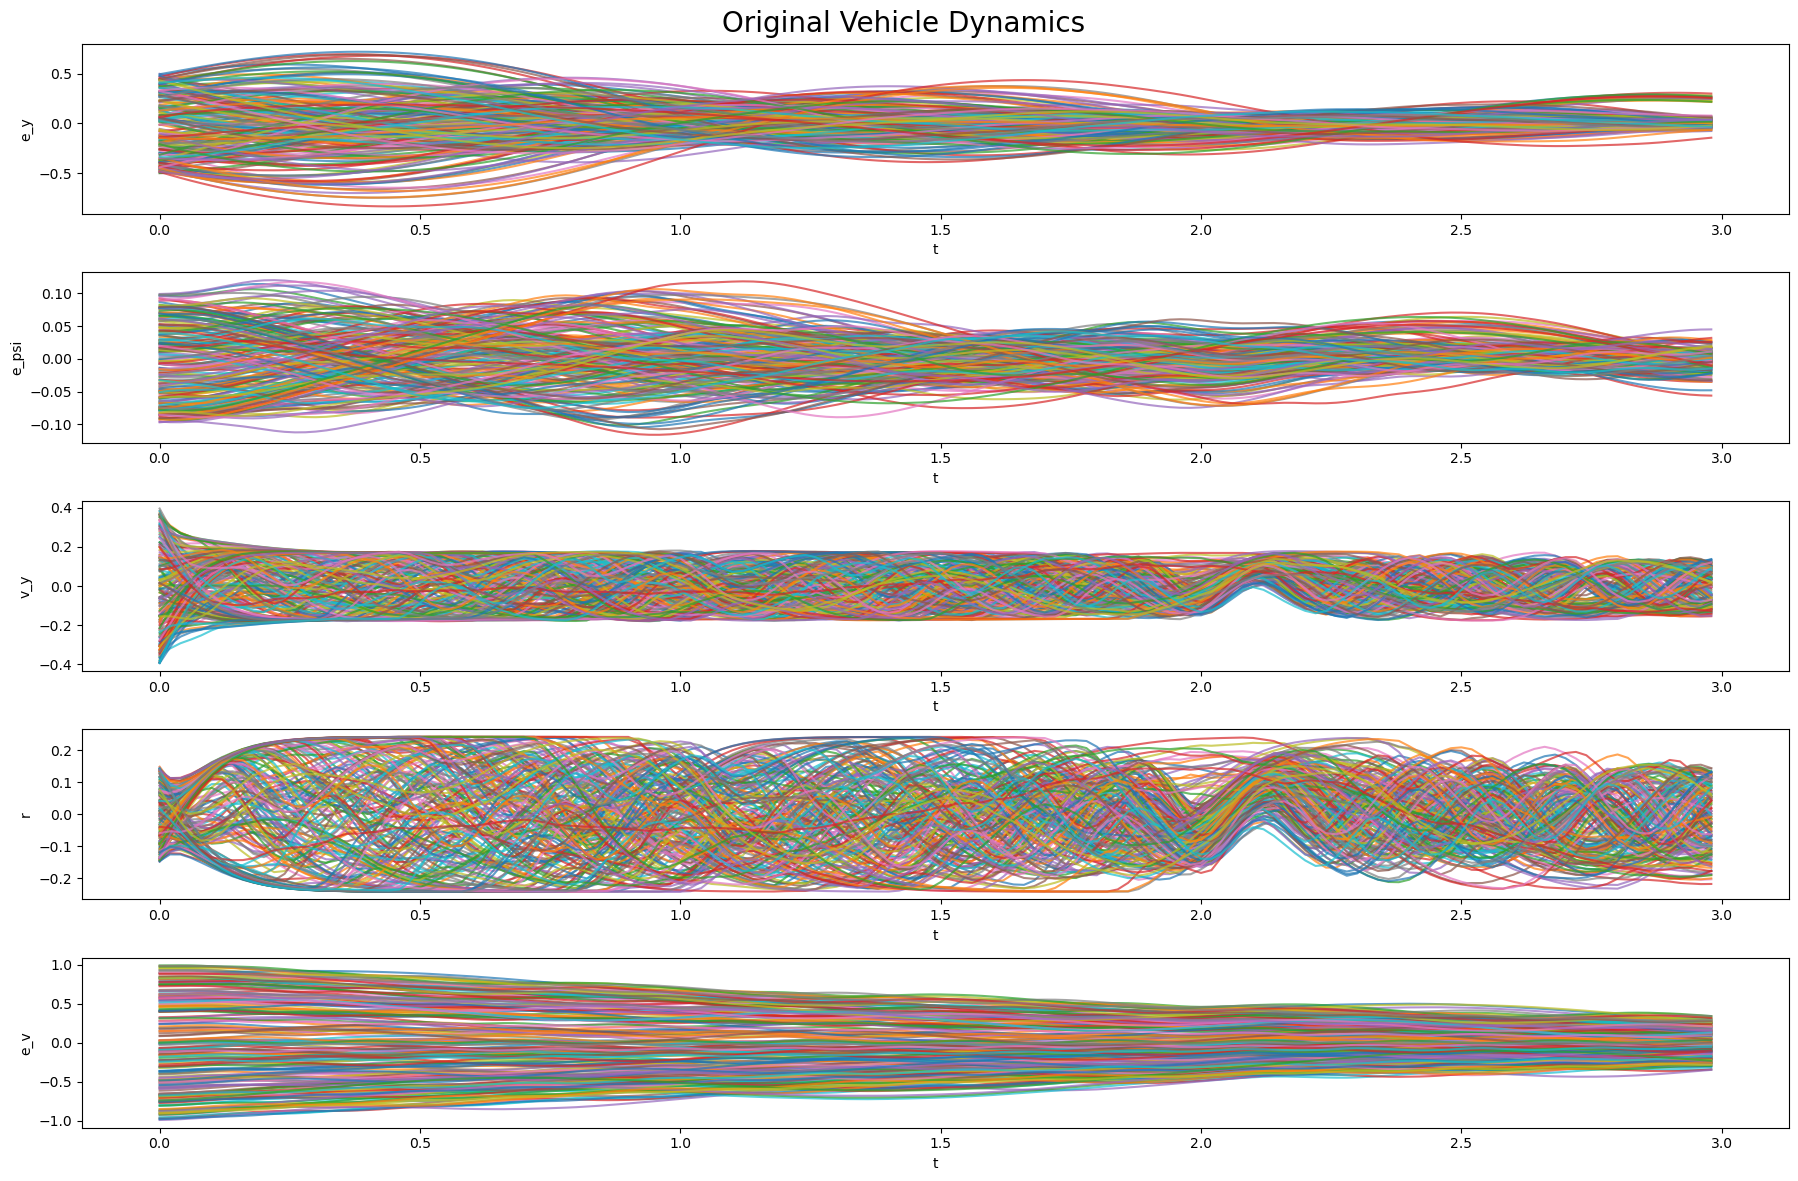

In [15]:
# Overall data
# leg = ['th','th_dot']

# t_train = np.linspace(0,dt*num_snaps,num_snaps)
# plt.figure(figsize = (20,10))
# for j in range(num_traj):
#     for i in range(N):
#         plt.subplot(N,2,2*i+1)
#         plt.xlabel("t")
#         plt.ylabel(leg[0]+str(i+1))
#         plt.plot(t_train,X[j,:,2*i])
#
#         plt.subplot(N,2,2*i+2)
#         plt.xlabel("t")
#         plt.ylabel(leg[1]+str(i+1))
#         plt.plot(t_train,X[j,:,2*i+1])
#
# plt.suptitle("Original Dynamics", fontsize=30)
# plt.show()
state_labels = ['e_y', 'e_psi', 'v_y', 'r', 'e_v']
input_labels = ['delta', 'a_x']
t_train = np.linspace(0, dt * (num_snaps - 1), num_snaps)

plt.figure(figsize=(18, 12))
for j in range(num_traj):
    for i in range(num_states):
        plt.subplot(num_states, 1, i + 1)
        plt.plot(t_train, X[j, :, i], alpha=0.7)
        plt.ylabel(state_labels[i])
        plt.xlabel("t")
plt.suptitle("Original Vehicle Dynamics", fontsize=20)
plt.tight_layout()
plt.show()

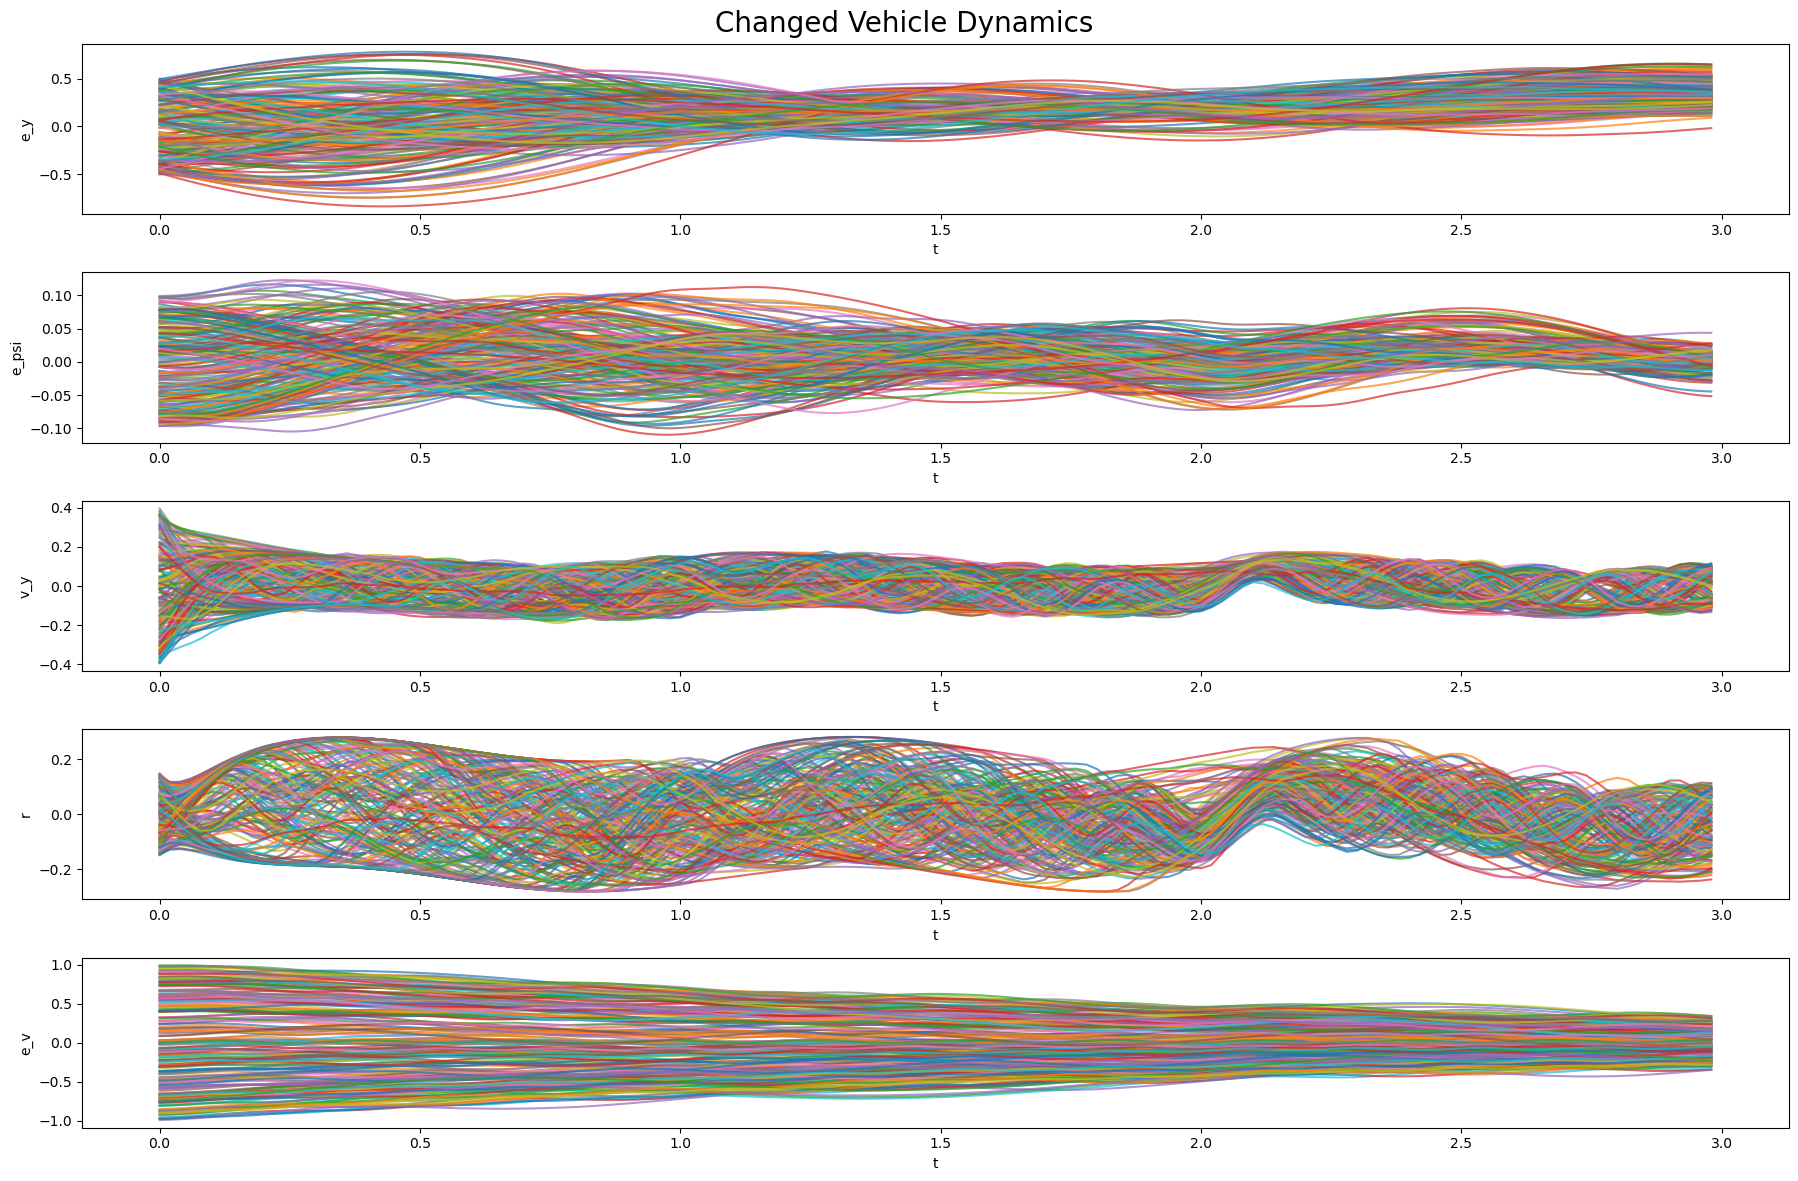

In [16]:
# plt.figure(figsize = (20,10))
# for j in range(num_traj):
#     for i in range(N):
#         plt.subplot(N,2,2*i+1)
#         plt.xlabel("t")
#         plt.ylabel(leg[0])
#         plt.plot(t_train,X[j,:,2*i])
#
#         plt.subplot(N,2,2*i+2)
#         plt.xlabel("t")
#         plt.ylabel(leg[1])
#         plt.plot(t_train,X_changed[j,:,2*i+1])
#
# plt.suptitle("Changed Dynamics", fontsize=30)
# plt.show()

plt.figure(figsize=(18, 12))
for j in range(num_traj):
    for i in range(num_states):
        plt.subplot(num_states, 1, i + 1)
        plt.plot(t_train, X_changed[j, :, i], alpha=0.7)
        plt.ylabel(state_labels[i])
        plt.xlabel("t")
plt.suptitle("Changed Vehicle Dynamics", fontsize=20)
plt.tight_layout()
plt.show()

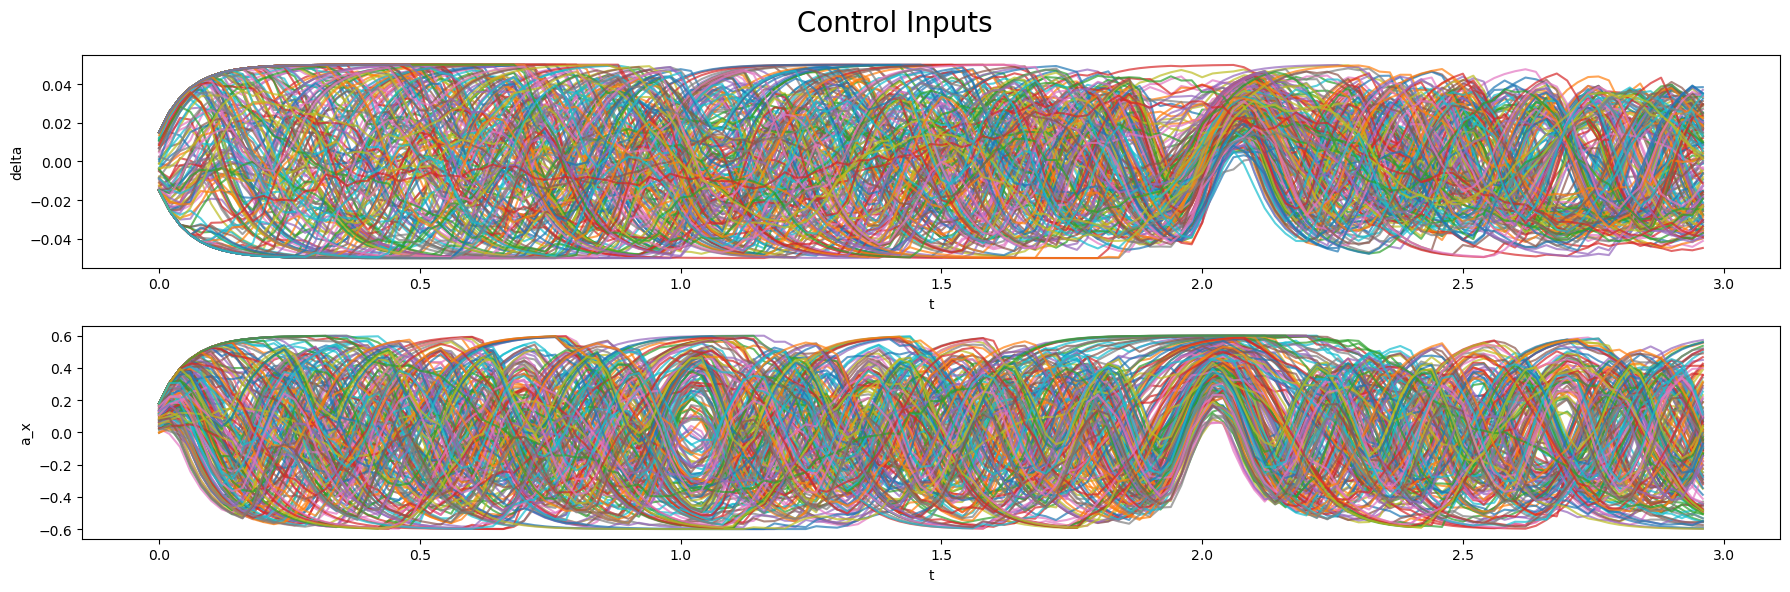

In [17]:
# plt.figure(figsize = (20,10))
# j = 10
# for i in range(num_states):
#     plt.subplot(N,2,i+1)
#     plt.plot(t_train,X[j,:,i])
#     plt.plot(t_train,X_changed[j,:,i])
#     plt.xlabel("t")
#     # plt.ylabel(leg[i])
# plt.suptitle("Comparison between Changed and original Dynamics", fontsize=30)
# plt.show()

plt.figure(figsize=(18, 6))
for j in range(num_traj):
    for i in range(num_inputs):
        plt.subplot(num_inputs, 1, i + 1)
        plt.plot(t_train[:-1], U[j, :, i], alpha=0.7)
        plt.ylabel(input_labels[i])
        plt.xlabel("t")
plt.suptitle("Control Inputs", fontsize=20)
plt.tight_layout()
plt.show()

In [18]:
# plt.figure(figsize = (20,5))
# for j in range(num_traj):
#     for i in range(int(num_inputs)):
#         plt.subplot(num_inputs,1,i+1)
#         plt.xlabel("t")
#         plt.ylabel("F")
#         plt.plot(t_train[:-1], U[j,:,i])
# plt.suptitle("Control Inputs", fontsize=30)
# plt.show()

## Learning Koopman Models

In [19]:
# split training and vaidation datasets
xs_train, us_train = X[:num_train,:,:],U[:num_train,:,:]
xs_val, us_val = X[num_train:,:,:],U[num_train:,:,:]

In [20]:
xs_train.shape, us_train.shape

((160, 150, 5), (160, 149, 2))

In [21]:
# # auto encoder parameters
# net_params_lin = {}
# net_params_lin['state_dim'] = num_states
# net_params_lin['ctrl_dim'] = num_inputs
# net_params_lin['encoder_hidden_width'] = 60
# net_params_lin['encoder_hidden_depth'] = 3
# net_params_lin['encoder_output_dim'] = 6
# net_params_lin['optimizer'] = 'adam'
# net_params_lin['activation_type'] = 'tanh'
# net_params_lin['lr'] = 2e-4 # 5e-4
# net_params_lin['epochs'] = 200
# net_params_lin['batch_size'] = 256
# net_params_lin['eig_loss'] = False
# net_params_lin['eig_loss_coeff'] = 1.1
# net_params_lin['lifted_loss_penalty'] = 0.4
# net_params_lin['l2_reg'] = 1e-5
# net_params_lin['l1_reg'] = 1e-5
# net_params_lin['first_obs_const'] = True
# net_params_lin['override_C'] = True # this makes the state a part of lifted state
# net_params_lin['dt'] = dt

# net_params_lin = {}
# net_params_lin['state_dim'] = num_states
# net_params_lin['ctrl_dim'] = num_inputs
# net_params_lin['encoder_hidden_width'] = 64
# net_params_lin['encoder_hidden_depth'] = 2
# net_params_lin['encoder_output_dim'] = 4
# net_params_lin['optimizer'] = 'adam'
# net_params_lin['activation_type'] = 'tanh'
# net_params_lin['lr'] = 2e-4
# net_params_lin['epochs'] = 200
# net_params_lin['batch_size'] = 256
# net_params_lin['eig_loss'] = False
# net_params_lin['eig_loss_coeff'] = 1.1
# net_params_lin['lifted_loss_penalty'] = 0.4
# net_params_lin['l2_reg'] = 1e-5
# net_params_lin['l1_reg'] = 1e-5
# net_params_lin['first_obs_const'] = True
# net_params_lin['override_C'] = True
# net_params_lin['dt'] = dt

net_params_lin = {}
net_params_lin['state_dim'] = num_states
net_params_lin['ctrl_dim'] = num_inputs
net_params_lin['encoder_hidden_width'] = 96
net_params_lin['encoder_hidden_depth'] = 2
net_params_lin['encoder_output_dim'] = 8
net_params_lin['optimizer'] = 'adam'
net_params_lin['activation_type'] = 'tanh'
net_params_lin['lr'] = 8e-5
net_params_lin['epochs'] = 500
net_params_lin['batch_size'] = 128
# net_params_lin['eig_loss'] = False
# net_params_lin['eig_loss_coeff'] = 1.1
# net_params_lin['lifted_loss_penalty'] = 1.0

net_params_lin['eig_loss'] = True
net_params_lin['eig_loss_coeff'] = 8.0
net_params_lin['lifted_loss_penalty'] = 0.8

net_params_lin['l2_reg'] = 2e-4
net_params_lin['l1_reg'] = 1e-6
net_params_lin['first_obs_const'] = True
net_params_lin['override_C'] = True
net_params_lin['dt'] = dt


In [22]:
# # Koopman Model
# train = False
# standardize = False
# # file_koop_linear = 'saved_models/sync_pendulum/linear/Koop_arch_N'+str(N)+'_L'+ str(sys_pars['l']) +'_Dim'+ str(net_params_lin['encoder_output_dim'])+'_dt_'+str(dt)+'.pth'
# file_koop_linear = (
#     'saved_models/single_vehicle/linear/'
#     + 'Koop_vehicle_Dim'
#     + str(net_params_lin['encoder_output_dim'])
#     + '_dt_'
#     + str(dt)
#     + '.pth'
# )
import os

# # Koopman Model
# train = True
# standardize = False

# Koopman Model
train = True
standardize = True

os.makedirs('saved_models/single_vehicle/linear', exist_ok=True)

file_koop_linear = (
    'saved_models/single_vehicle/linear/'
    + 'Koop_vehicle_Dim'
    + str(net_params_lin['encoder_output_dim'])
    + '_dt_'
    + str(dt)
    + '.pth'
)

In [23]:
file_koop_linear

'saved_models/single_vehicle/linear/Koop_vehicle_Dim8_dt_0.02.pth'

In [24]:
standardizer_u_kdnn = fit_standardizer(
    us_train, preprocessing.StandardScaler(with_mean=True)
)
standardizer_x_kdnn = fit_standardizer(
    xs_train, preprocessing.StandardScaler(with_mean=True)
)

In [25]:
# standardizer_u_kdnn = fit_standardizer(us_train, preprocessing.StandardScaler(with_mean = True))
# standardizer_x_kdnn = fit_standardizer(xs_train, preprocessing.StandardScaler(with_mean = False))

In [26]:


if train == True:
    if standardize:
        net = KoopmanNetCtrl_linear(net_params_lin, standardizer_x=standardizer_x_kdnn, standardizer_u=standardizer_u_kdnn)
    else:
        net = KoopmanNetCtrl_linear(net_params_lin)
    model_koop_dnn_lin = KoopDNN_linear(net)
    model_koop_dnn_lin.set_datasets(xs_train, u_train=us_train, x_val=xs_val, u_val=us_val)
    model_koop_dnn_lin.model_pipeline(net_params_lin)
    model_koop_dnn_lin.construct_koopman_model()
    torch.save(model_koop_dnn_lin,file_koop_linear)
else:
    model_koop_dnn_lin = torch.load(file_koop_linear, weights_only=True)

Epoch   1: train loss: 1.4456419945, validation loss: 1.3220923074
Epoch   2: train loss: 1.1416434050, validation loss: 1.0607128257
Epoch   3: train loss: 0.9842794538, validation loss: 0.9243708342
Epoch   4: train loss: 0.8949949741, validation loss: 0.8470554491
Epoch   5: train loss: 0.8396708965, validation loss: 0.7982814902
Epoch   6: train loss: 0.8013279438, validation loss: 0.7637562314
Epoch   7: train loss: 0.7712776661, validation loss: 0.7359604493
Epoch   8: train loss: 0.7448133230, validation loss: 0.7117647332
Epoch   9: train loss: 0.7217186689, validation loss: 0.6892121244
Epoch  10: train loss: 0.6993519068, validation loss: 0.6683393514
Epoch  11: train loss: 0.6785322428, validation loss: 0.6483116093
Epoch  12: train loss: 0.6593046784, validation loss: 0.6288916481
Epoch  13: train loss: 0.6390614510, validation loss: 0.6099486738
Epoch  14: train loss: 0.6212475896, validation loss: 0.5916106948
Epoch  15: train loss: 0.6014370322, validation loss: 0.573119

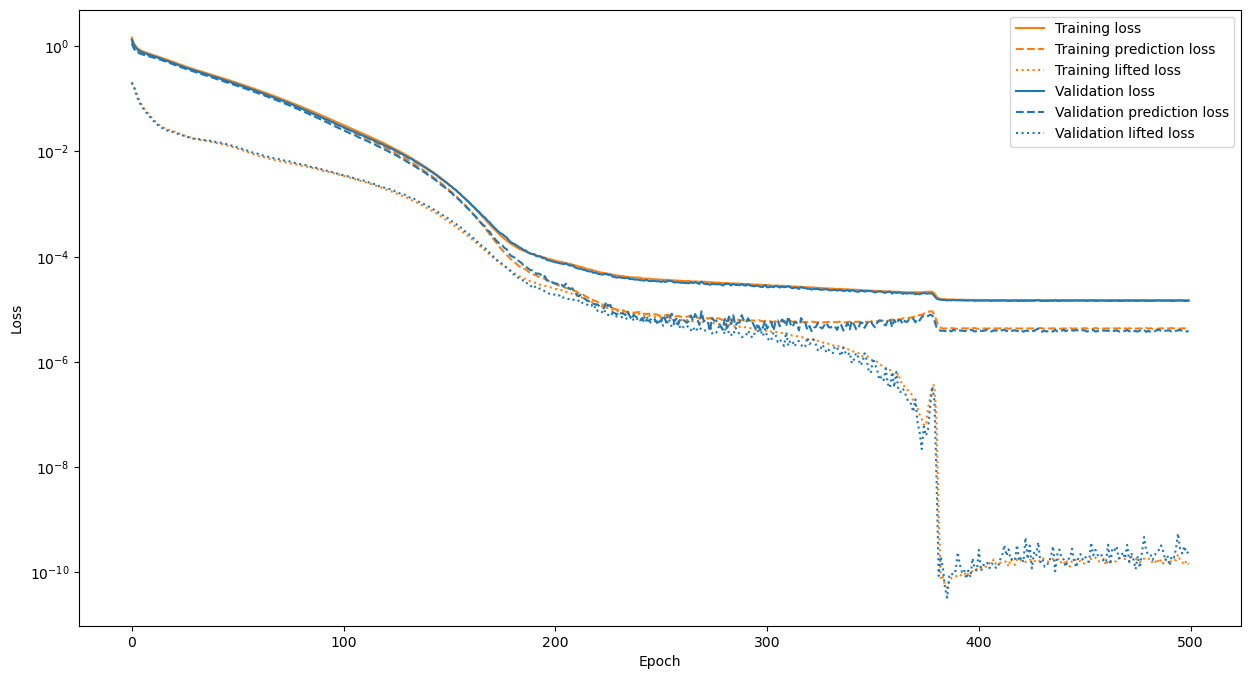

In [27]:
train_loss = [l[0] for l in model_koop_dnn_lin.train_loss_hist]
train_pred_loss = [l[1] for l in model_koop_dnn_lin.train_loss_hist]
train_lifted_loss = [l[2] for l in model_koop_dnn_lin.train_loss_hist]
val_loss = [l[0] for l in model_koop_dnn_lin.val_loss_hist]
val_pred_loss = [l[1] for l in model_koop_dnn_lin.val_loss_hist]
val_lifted_loss = [l[2] for l in model_koop_dnn_lin.val_loss_hist]
epochs = np.arange(0, net_params_lin['epochs'])

plt.figure(figsize=(15,8))
plt.plot(epochs, train_loss, color='tab:orange', label='Training loss')
plt.plot(epochs, train_pred_loss, '--', color='tab:orange', label='Training prediction loss')
plt.plot(epochs, train_lifted_loss, ':', color='tab:orange', label='Training lifted loss')
plt.plot(epochs, val_loss, color='tab:blue', label='Validation loss')
plt.plot(epochs, val_pred_loss, '--', color='tab:blue', label='Validation prediction loss')
plt.plot(epochs, val_lifted_loss, ':', color='tab:blue', label='Validation lifted loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.show()

## Koopman Model Parameters

In [28]:
# test data parameters
# num_snaps_test = 1000 # no. of snapshots
# T_test = np.linspace(0,(num_snaps_test-1)*dt, num_snaps_test)

num_snaps_test = 100
T_test = np.linspace(0, (num_snaps_test - 1) * dt, num_snaps_test)

num_traj_test = 1 # no. of training examples
first_obs_const = int(net_params_lin['first_obs_const']) #only one state
override_C = net_params_lin['override_C']
if override_C:
    n_obs_lin = int(net_params_lin['encoder_output_dim']) + num_states + first_obs_const
else:
    n_obs_lin = int(net_params_lin['encoder_output_dim']) + first_obs_const

In [29]:
#generate data for testing
# x_unchanged_test, x_changed_test, u_test = sync_pendulum_data_gen_multi(num_traj_test, num_snaps_test, sys_pars, sys_pars_new, sensor_noise,SNR_DB)
x_unchanged_test, x_changed_test, u_test = single_vehicle_data_gen_multi(
    num_traj_test, num_snaps_test, sys_pars, sys_pars_new, sensor_noise, SNR_DB
)

In [30]:
x_unchanged_test.shape, x_changed_test.shape, u_test.shape

((1, 100, 5), (1, 100, 5), (1, 99, 2))

stable spectral radius = 0.9990001
(14, 14) (14, 2) (5, 14)
spectral radius = 1.0000055
eigvals = [0.7164227 +5.8703501e-02j 0.7164227 -5.8703501e-02j
 0.99997574+1.4725623e-03j 0.99997574-1.4725623e-03j
 1.0000055 +0.0000000e+00j 0.99999994+2.1277324e-06j
 0.99999994-2.1277324e-06j 0.99999875+1.0653534e-06j
 0.99999875-1.0653534e-06j 0.9999966 +1.9465442e-06j
 0.9999966 -1.9465442e-06j 0.9999957 +0.0000000e+00j
 0.9999967 +0.0000000e+00j 1.        +0.0000000e+00j]


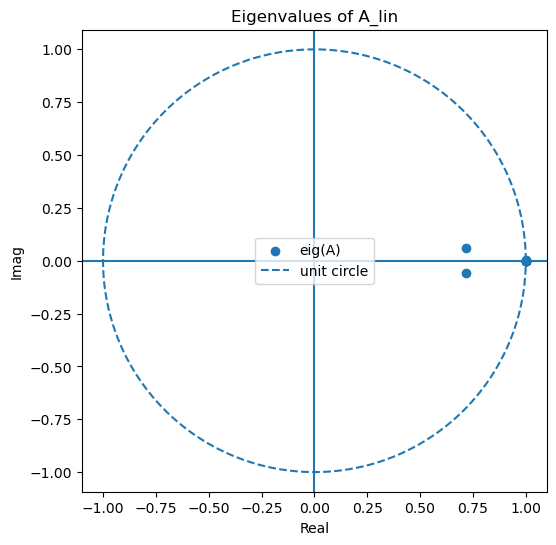

In [31]:
A_lin = np.array(model_koop_dnn_lin.A)
B_lin = np.array(model_koop_dnn_lin.B)
C_lin = np.array(model_koop_dnn_lin.C)

eigvals, eigvecs = np.linalg.eig(A_lin)
eigvals_proj = np.array([ev / max(1.0, np.abs(ev)) * 0.999 for ev in eigvals])
A_lin_stable = eigvecs @ np.diag(eigvals_proj) @ np.linalg.inv(eigvecs)
A_lin_stable = np.real(A_lin_stable)

eigvals_stable = np.linalg.eigvals(A_lin_stable)
print("stable spectral radius =", np.max(np.abs(eigvals_stable)))

print(A_lin.shape, B_lin.shape, C_lin.shape)

eigvals = np.linalg.eigvals(A_lin)
spectral_radius = np.max(np.abs(eigvals))

print("spectral radius =", spectral_radius)
print("eigvals =", eigvals)

plt.figure(figsize=(6, 6))
plt.scatter(np.real(eigvals), np.imag(eigvals), label='eig(A)')
theta = np.linspace(0, 2*np.pi, 400)
plt.plot(np.cos(theta), np.sin(theta), '--', label='unit circle')
plt.axhline(0)
plt.axvline(0)
plt.xlabel('Real')
plt.ylabel('Imag')
plt.legend()
plt.title('Eigenvalues of A_lin')
plt.axis('equal')
plt.show()


X_unchanged,_ = model_koop_dnn_lin.net.process(x_unchanged_test,data_u = u_test)
X_changed,_ = model_koop_dnn_lin.net.process(x_changed_test,data_u = u_test)

In [32]:
X_unchanged.shape, X_changed.shape

((99, 12), (99, 12))

In [33]:
x_unchanged = X_unchanged[:, :num_states]
u = X_unchanged[:, num_states:num_states+num_inputs]
x_unchanged_prime = X_unchanged[:,num_states+num_inputs:]

x_changed = X_changed[:, :num_states]
x_changed_prime = X_changed[:,num_states+num_inputs:]

In [34]:
x_changed.shape, x_changed_prime.shape, x_unchanged.shape

((99, 5), (99, 5), (99, 5))

x_unchanged shape: (99, 5)
u shape: (99, 2)


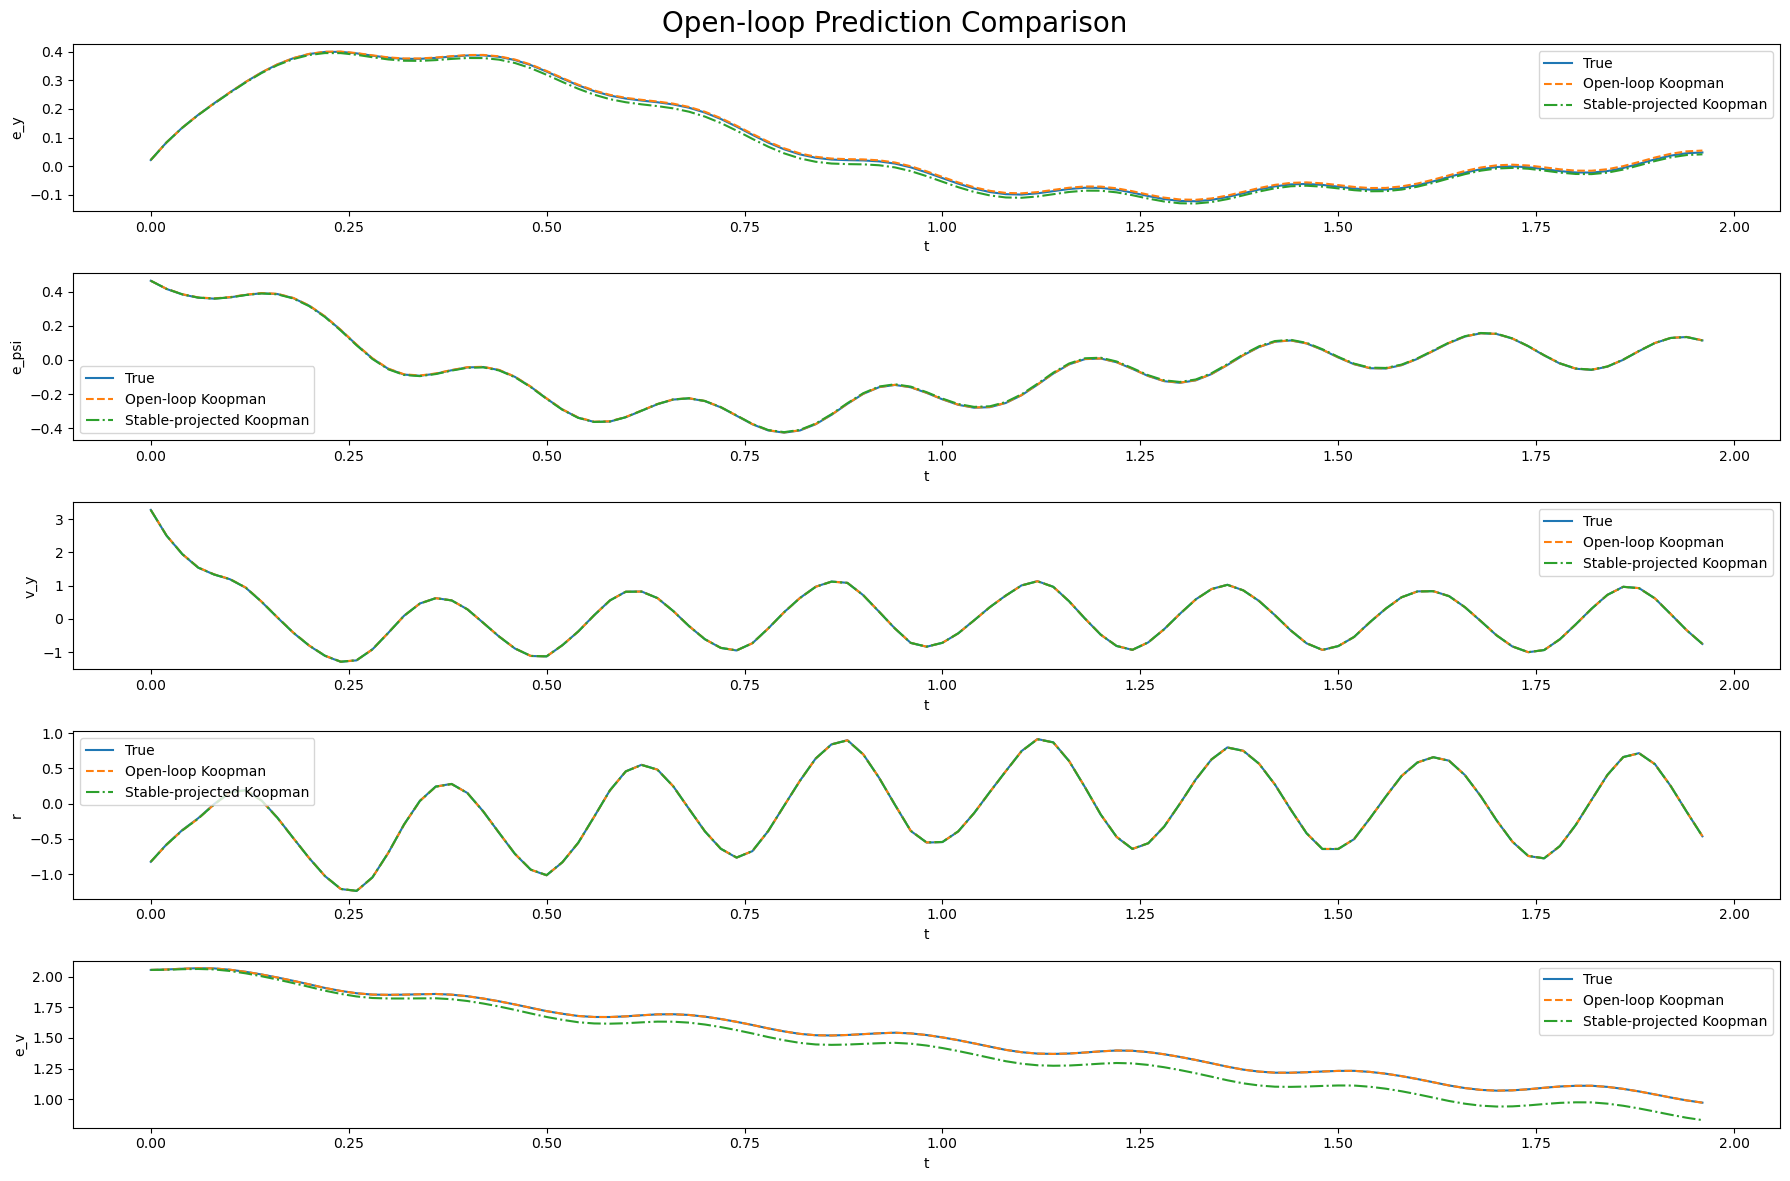

In [35]:
# # # initialize states
# # z_lin = np.zeros((n_obs_lin,num_snaps_test+1)).T   #lifted state
# # x_est_lin = np.zeros((num_states,num_snaps_test+1)).T #estimated values
# # z_lin[0,:] = lift(x_unchanged[0,:],model_koop_dnn_lin, net_params_lin)
# # x_est_lin[0,:] = np.matmul(z_lin[0,:],C_lin.T)
# z_lin = np.zeros((num_snaps_test, n_obs_lin))
# x_est_lin = np.zeros((num_snaps_test, num_states))
#
# z_lin[0, :] = lift(x_unchanged[0, :], model_koop_dnn_lin, net_params_lin)
# x_est_lin[0, :] = np.matmul(z_lin[0, :], C_lin.T)
#
# for i in range(num_snaps_test - 1):
#     z_lin[i + 1, :] = np.matmul(z_lin[i, :], A_lin.T) + np.matmul(u[i, :], B_lin.T)
#     x_est_lin[i + 1, :] = np.matmul(z_lin[i + 1, :], C_lin.T)
# 先看真实长度
print("x_unchanged shape:", x_unchanged.shape)
print("u shape:", u.shape)

num_pred = x_unchanged.shape[0]

z_lin = np.zeros((num_pred, n_obs_lin))
x_est_lin = np.zeros((num_pred, num_states))

z_lin[0, :] = lift(x_unchanged[0, :], model_koop_dnn_lin, net_params_lin)
x_est_lin[0, :] = np.matmul(z_lin[0, :], C_lin.T)

for k in range(num_pred - 1):
    z_lin[k + 1, :] = np.matmul(z_lin[k, :], A_lin.T) + np.matmul(u[k, :], B_lin.T)
    x_est_lin[k + 1, :] = np.matmul(z_lin[k + 1, :], C_lin.T)

z_lin_stable = np.zeros((num_pred, n_obs_lin))
x_est_lin_stable = np.zeros((num_pred, num_states))

z_lin_stable[0, :] = lift(x_unchanged[0, :], model_koop_dnn_lin, net_params_lin)
x_est_lin_stable[0, :] = np.matmul(z_lin_stable[0, :], C_lin.T)

for k in range(num_pred - 1):
    z_lin_stable[k + 1, :] = np.matmul(z_lin_stable[k, :], A_lin_stable.T) + np.matmul(u[k, :], B_lin.T)
    x_est_lin_stable[k + 1, :] = np.matmul(z_lin_stable[k + 1, :], C_lin.T)

T_plot = np.arange(num_pred) * dt

plt.figure(figsize=(18, 12))
for i in range(num_states):
    plt.subplot(num_states, 1, i + 1)
    plt.xlabel("t")
    plt.ylabel(state_labels[i])
    plt.plot(T_plot, x_unchanged[:, i], label='True')
    plt.plot(T_plot, x_est_lin[:, i], '--', label='Open-loop Koopman')
    plt.plot(T_plot, x_est_lin_stable[:, i], '-.', label='Stable-projected Koopman')
    plt.legend()

plt.suptitle("Open-loop Prediction Comparison", fontsize=20)
plt.tight_layout()
plt.show()

In [36]:
#compute the trajectory predicted by the Koopman model
# for i in range(num_snaps_test-1):
#
#     z_lin[i+1,:] = np.matmul(z_lin[i,:],A_lin.T)+np.matmul(u[i,:],B_lin.T)
#     x_est_lin[i+1,:] = np.matmul(z_lin[i+1,:],C_lin.T)

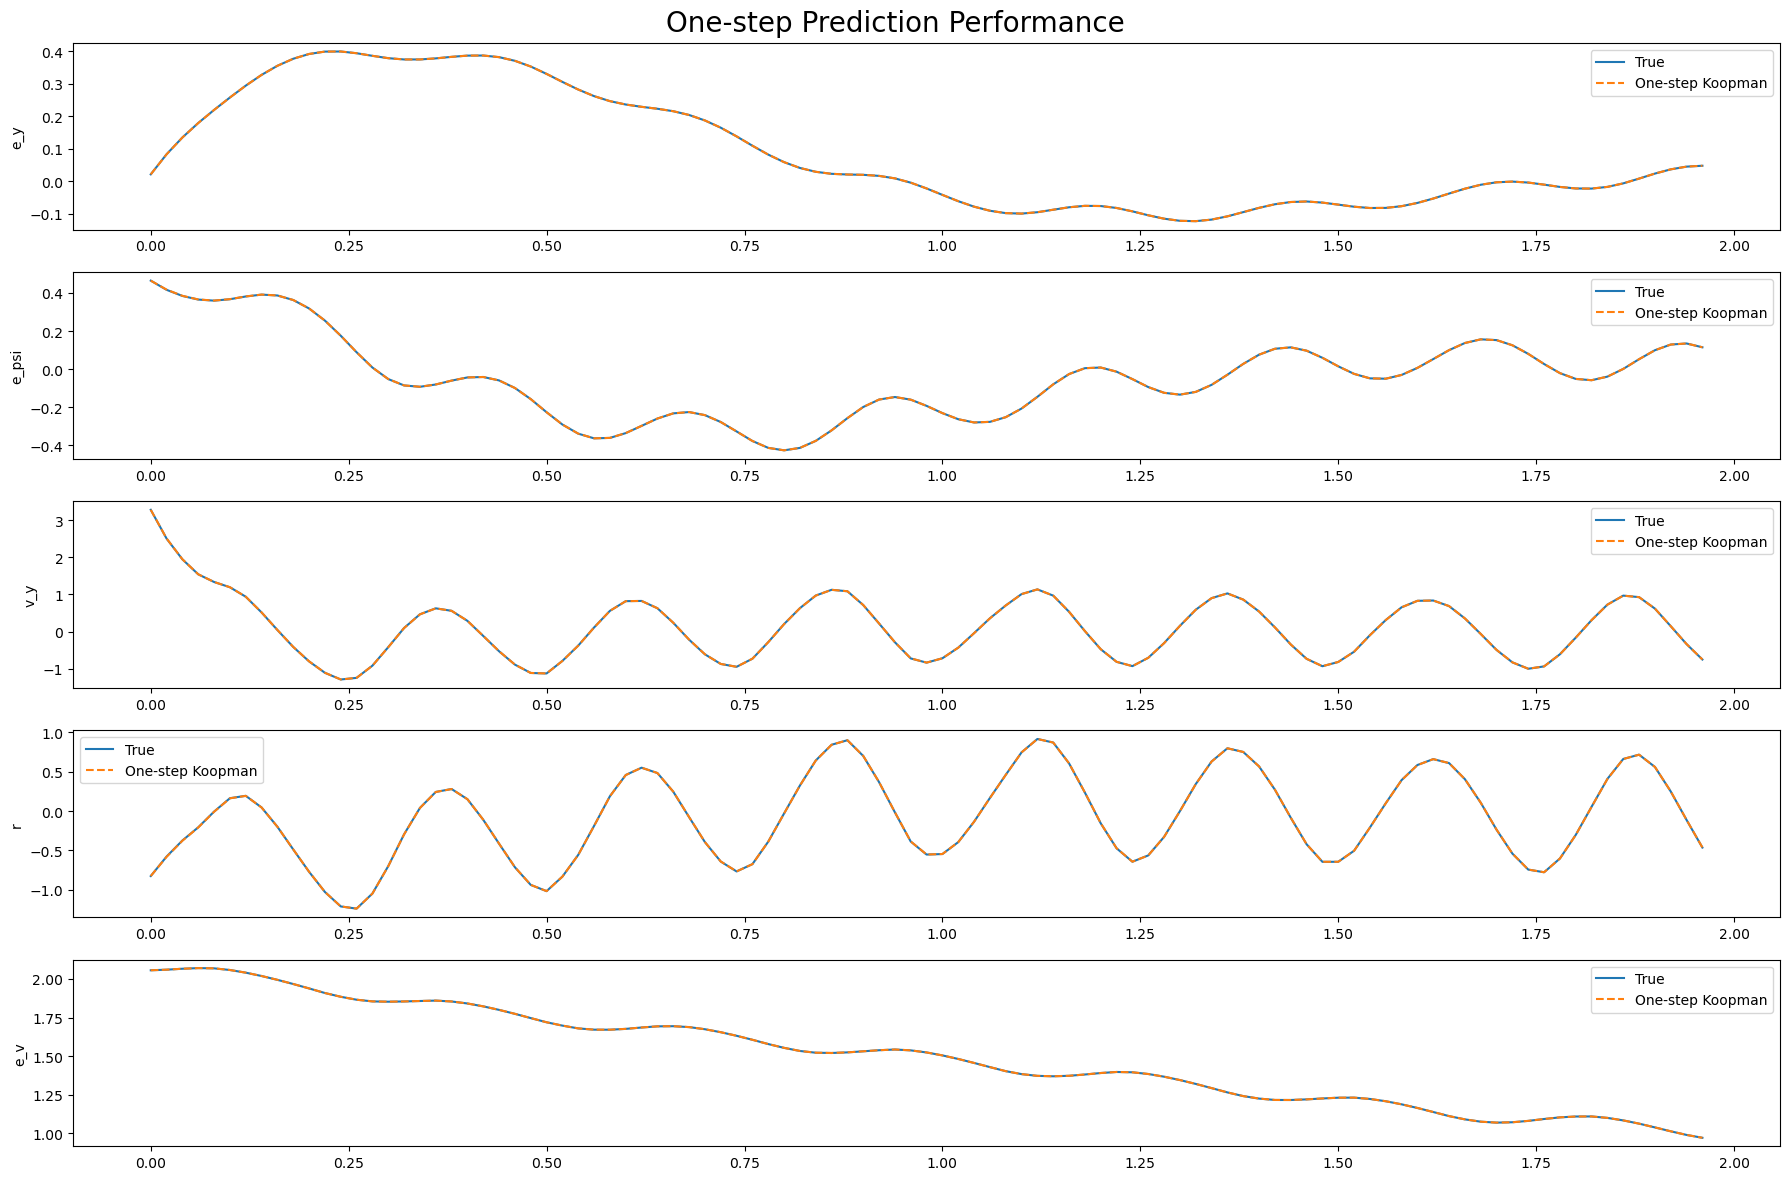

In [37]:
# # # # state estimation evolution
# # # plt.figure(figsize=(20, 10))
# # # for i in range(int(num_states)):
# # #     plt.subplot(N,2,i+1)
# # #     plt.xlabel("t")
# # #     # plt.ylabel(leg[i])
# # #     plt.plot(T_test[:-1], x_unchanged[:,i],label ='Original Dynamics')
# # #     plt.plot(T_test, x_est_lin[:-1,i],label = 'estimated Original (linear)')
# # #     plt.legend()
# # # plt.suptitle("Testing Performance", fontsize=30)
# # # plt.show()
# #
# # plt.figure(figsize=(18, 12))
# # for i in range(num_states):
# #     plt.subplot(num_states, 1, i + 1)
# #     plt.xlabel("t")
# #     plt.ylabel(state_labels[i])
# #     plt.plot(T_test[:-1], x_unchanged[:, i], label='Original Dynamics')
# #     plt.plot(T_test[:-1], x_est_lin[:-1, i], '--', label='Koopman Prediction')
# #     plt.legend()
# # plt.suptitle("Open-loop Prediction Performance", fontsize=20)
# # plt.tight_layout()
# # plt.show()
# plt.figure(figsize=(18, 12))
# for i in range(num_states):
#     plt.subplot(num_states, 1, i + 1)
#     plt.xlabel("t")
#     plt.ylabel(state_labels[i])
#     plt.plot(T_test, x_unchanged[:, i], label='Original Dynamics')
#     plt.plot(T_test, x_est_lin[:, i], '--', label='Koopman Prediction')
#     plt.legend()
# plt.suptitle("Open-loop Prediction Performance", fontsize=20)
# plt.tight_layout()
# plt.show()
T_plot = np.arange(num_pred) * dt
x_one_step = np.zeros_like(x_unchanged)
x_one_step[0, :] = x_unchanged[0, :]

for k in range(num_pred - 1):
    z_k = lift(x_unchanged[k, :], model_koop_dnn_lin, net_params_lin)
    z_k1 = np.matmul(z_k, A_lin.T) + np.matmul(u[k, :], B_lin.T)
    x_one_step[k + 1, :] = np.matmul(z_k1, C_lin.T)

plt.figure(figsize=(18, 12))
for i in range(num_states):
    plt.subplot(num_states, 1, i + 1)
    plt.plot(T_plot, x_unchanged[:, i], label='True')
    plt.plot(T_plot, x_one_step[:, i], '--', label='One-step Koopman')
    plt.ylabel(state_labels[i])
    plt.legend()
plt.suptitle("One-step Prediction Performance", fontsize=20)
plt.tight_layout()
plt.show()

# T_plot = np.arange(num_pred) * dt
#
# plt.figure(figsize=(18, 12))
# for i in range(num_states):
#     plt.subplot(num_states, 1, i + 1)
#     plt.xlabel("t")
#     plt.ylabel(state_labels[i])
#     plt.plot(T_plot, x_unchanged[:, i], label='Original Dynamics')
#     plt.plot(T_plot, x_est_lin[:, i], '--', label='Koopman Prediction')
#     plt.legend()
#
# plt.suptitle("Open-loop Prediction Performance", fontsize=20)
# plt.tight_layout()
# plt.show()

## Testing

## Adaptive Koopman with Control

In [38]:
# from core.adapt_net_linear import AdaptNet_linear

In [39]:
"""Simultaneous adaptation and control"""

'Simultaneous adaptation and control'

In [40]:
# from control_files.nmpc_osqp_adapt import NonlinearMPCController
# from control_files.bmpc_osqp_adapt import bilinearMPCController
# from dynamics.learned_models_control.bilinear_dynamics import bilinear_Dynamics
# from dynamics.learned_models_control.linear_dynamics import linear_Dynamics
# import scipy
# import time

In [41]:
# T_traj = 10
# offset = np.zeros(num_states)
#
# t_ref = np.arange(0, T_traj, dt)
# traj_length = t_ref.size
#
# x_ref = np.zeros((num_states, traj_length))
# # T_traj = 20 #length of trajectory
# # offset = 0*np.array([5,1,1,0.5]) #initial offset
#
# t_ref = np.arange(0, T_traj, dt)    # Simulation time points, closed loop
# traj_length = t_ref.size
# # x_ref = np.zeros((num_states,traj_length))
# # phi_dot_ref = 40 #reference angular velocity
# # for i in range(traj_length):
# #     x_ref[::2,i] = phi_dot_ref*i*dt #reference angles
# #     x_ref[1::2,i] = phi_dot_ref #reference angular velocities
# T_traj = 10
# t_ref = np.arange(0, T_traj, dt)
# traj_length = t_ref.size
#
# # tracking target: all errors go to zero
# x_ref = np.zeros((num_states, traj_length))

In [42]:
# # # state estimation evolution
# # leg_y = ['x','theta','x_dot', 'theta_dot']
# # plt.figure(figsize=(20, 10))
# # for i in range(num_states):
# #     plt.subplot(N,2,i+1)
# #     plt.xlabel("t")
# #     # plt.ylabel(leg_y[i])
# #     plt.plot(x_ref[i,:])
# # plt.suptitle("y ref traj", fontsize=30)
# plt.figure(figsize=(18, 10))
# for i in range(num_states):
#     plt.subplot(num_states, 1, i + 1)
#     plt.xlabel("t")
#     plt.ylabel(state_labels[i])
#     plt.plot(t_ref, x_ref[i, :])
# plt.suptitle("Reference Trajectory", fontsize=20)
# plt.tight_layout()
# plt.show()

In [43]:
# # ===== closed-loop reference trajectory =====
# T_traj = 4.0
# offset = np.zeros(num_states)
#
# t_ref = np.arange(0, T_traj, dt)
# traj_length = t_ref.size
#
# # regulation task: drive all error states to zero
# x_ref = np.zeros((num_states, traj_length))
#
# plt.figure(figsize=(18, 10))
# for i in range(num_states):
#     plt.subplot(num_states, 1, i + 1)
#     plt.plot(t_ref, x_ref[i, :])
#     plt.ylabel(state_labels[i])
#     plt.xlabel("t")
# plt.suptitle("Reference Trajectory", fontsize=20)
# plt.tight_layout()
# plt.show()

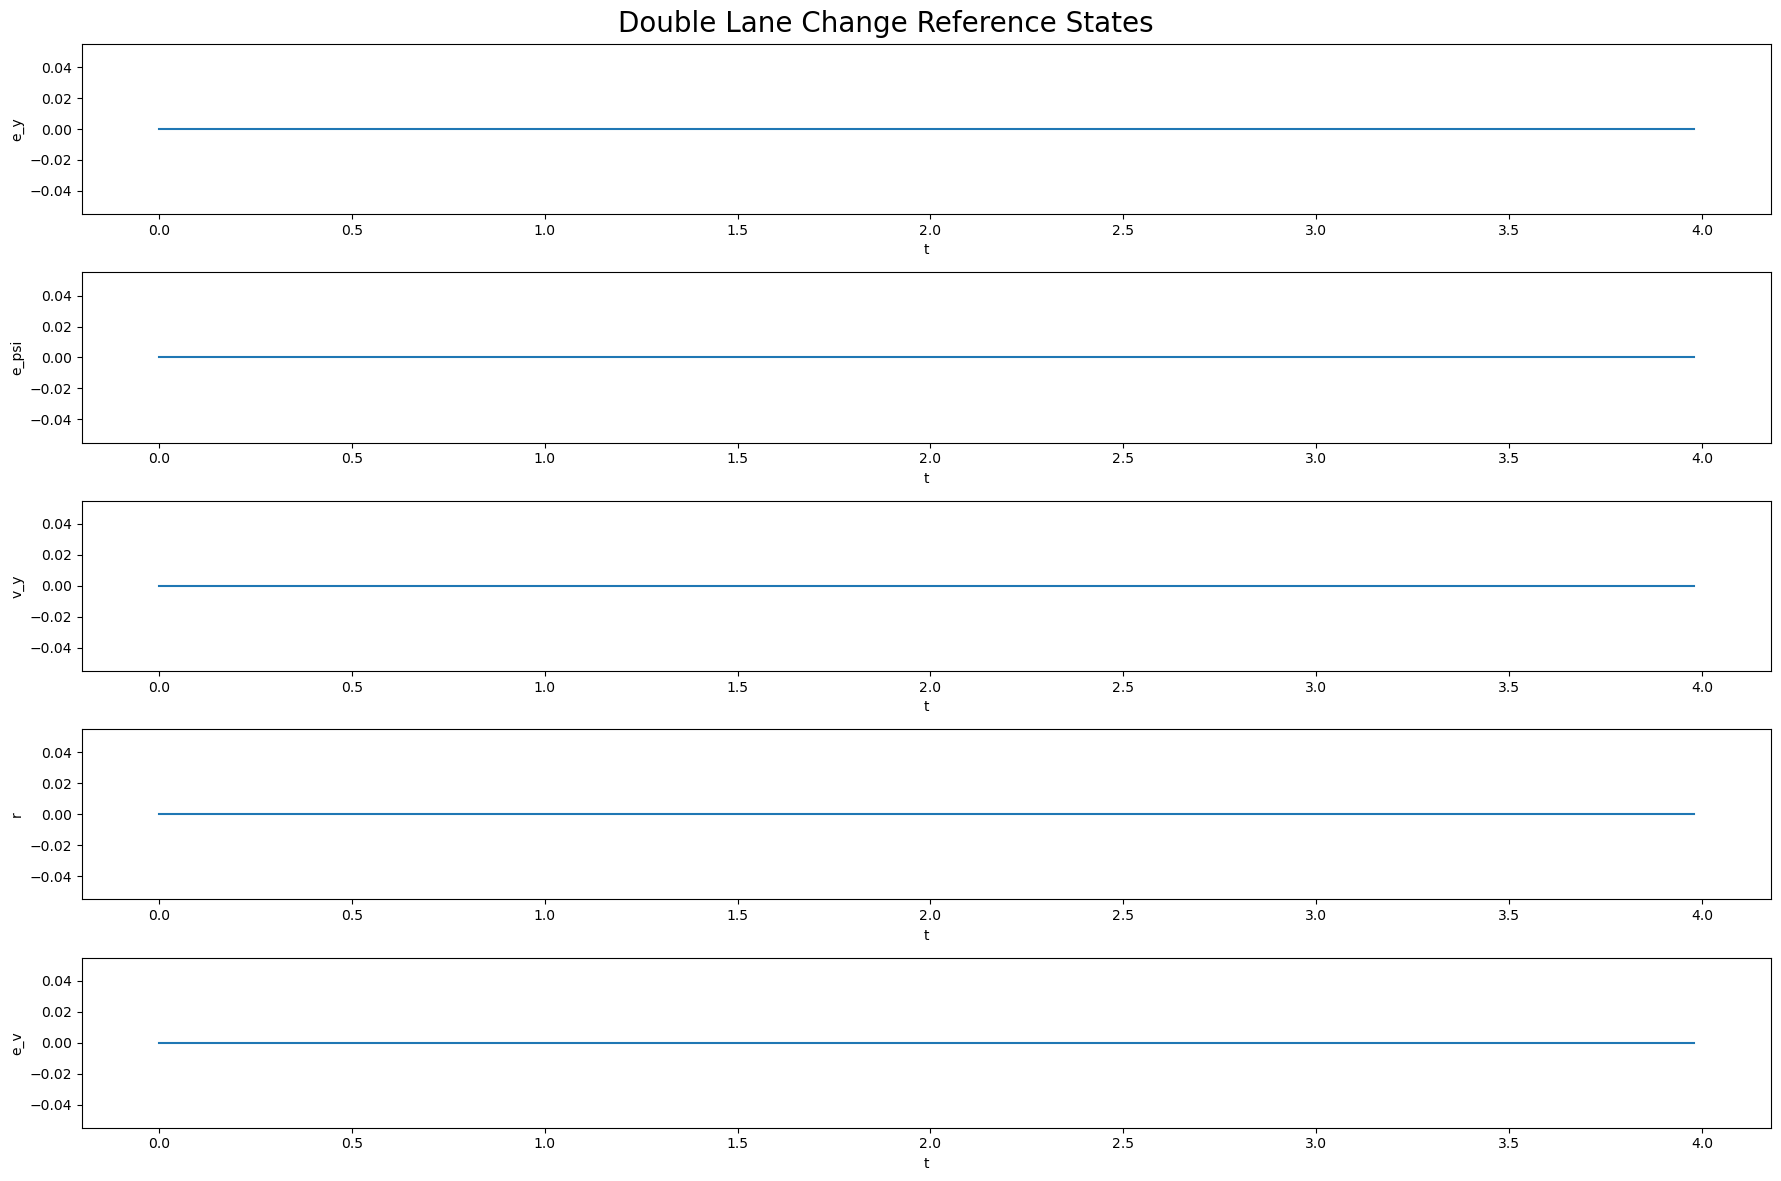

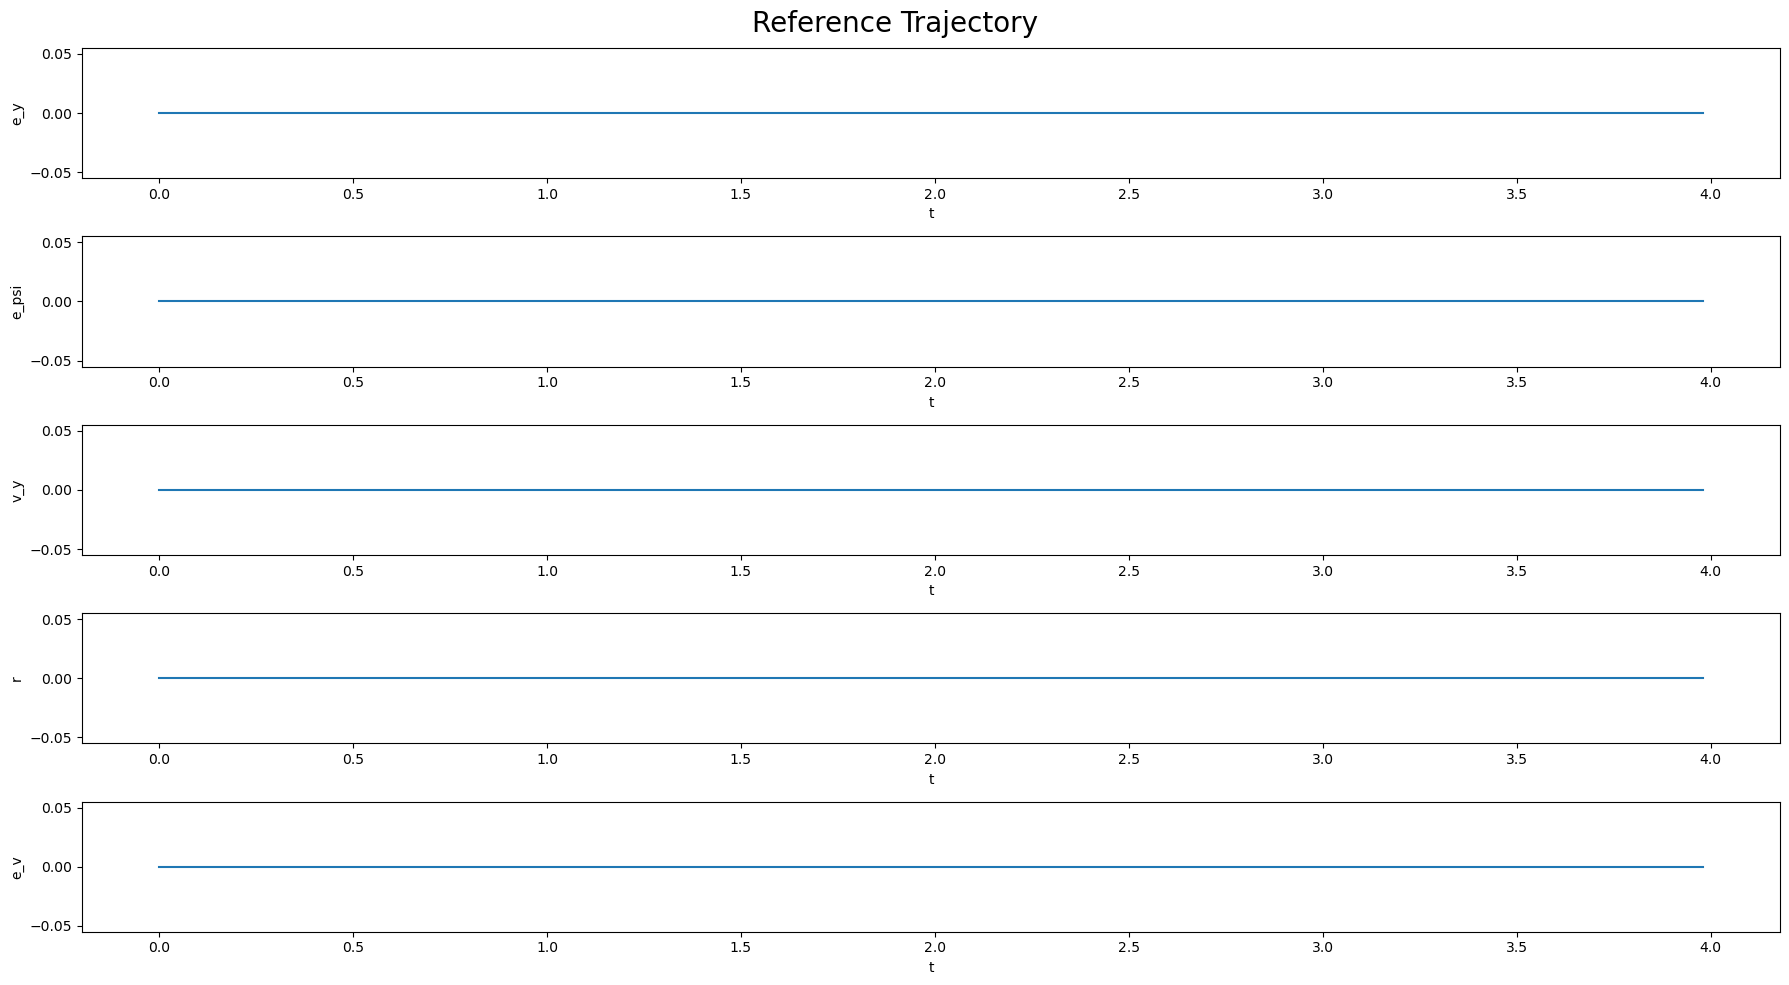

In [46]:
import scipy
from control_files.nmpc_osqp_adapt import NonlinearMPCController
from dynamics.learned_models_control.linear_dynamics import linear_Dynamics

# ===== closed-loop reference trajectory =====
# T_traj = 4.0
# offset = np.zeros(num_states)
#
# t_ref = np.arange(0, T_traj, dt)
# traj_length = t_ref.size
#
# x_ref = np.zeros((num_states, traj_length))

# ===== closed-loop reference trajectory: double lane change =====
T_traj = 4.0
t_ref = np.arange(0, T_traj, dt)
traj_length = t_ref.size

vx_nom = sys_pars['vx_ref']
x_path = vx_nom * t_ref   # 近似纵向位置

# -------- double lane change path parameters --------
# # A1 = 0.8    # 第一次横移幅值（m）
# # A2 = -0.8   # 第二次横移幅值（m）
# # x1 = 8.0    # 第一次变道中心位置（m）
# # x2 = 22.0   # 第二次变道中心位置（m）
# # sigma1 = 2.5
# # sigma2 = 2.5
A1 = 0.4
A2 = -0.4
x1 = 10.0
x2 = 28.0
sigma1 = 4.0
sigma2 = 4.0
# # 双移线横向轨迹：两个高斯包/双S叠加
y_ref_path = (
    A1 * np.exp(-0.5 * ((x_path - x1) / sigma1) ** 2)
    + A2 * np.exp(-0.5 * ((x_path - x2) / sigma2) ** 2)
)

# 一阶导：dy/dx
dy_dx = np.gradient(y_ref_path, x_path)

# 参考航向角（小角度下可近似 arctan(dy/dx)）
psi_ref_path = np.arctan(dy_dx)

# 参考横摆角速度 r_ref = d(psi_ref)/dt
r_ref_path = np.gradient(psi_ref_path, t_ref)

# 组装参考状态
x_ref = np.zeros((num_states, traj_length))

x_ref[0, :] = y_ref_path          # e_y_ref
x_ref[1, :] = psi_ref_path        # e_psi_ref
x_ref[2, :] = 0.0                 # v_y_ref
x_ref[3, :] = r_ref_path          # r_ref
x_ref[4, :] = 0.0                 # e_v_ref
x_ref[0, :] = 0.2 * np.sin(0.5 * 2 * np.pi * t_ref)
# 画参考状态
x_ref = np.zeros((num_states, traj_length))


plt.figure(figsize=(18, 12))
for i in range(num_states):
    plt.subplot(num_states, 1, i + 1)
    plt.plot(t_ref, x_ref[i, :])
    plt.ylabel(state_labels[i])
    plt.xlabel("t")
plt.suptitle("Double Lane Change Reference States", fontsize=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(18, 10))
for i in range(num_states):
    plt.subplot(num_states, 1, i + 1)
    plt.plot(t_ref, x_ref[i, :])
    plt.ylabel(state_labels[i])
    plt.xlabel("t")
plt.suptitle("Reference Trajectory", fontsize=20)
plt.tight_layout()
plt.show()

In [47]:
"""tracking without adaptation (use stable-projected A)"""
begin_linear_noadapt = time.time()

def to_numpy(x):
    if hasattr(x, 'detach'):
        return x.detach().cpu().numpy()
    return np.array(x)

# Koopman matrices
A_lin = to_numpy(model_koop_dnn_lin.A)
B_lin = to_numpy(model_koop_dnn_lin.B)
C_lin = to_numpy(model_koop_dnn_lin.C)

# ===== stable projection of A =====
eigvals, eigvecs = np.linalg.eig(A_lin)
eigvals_proj = np.array([ev / max(1.0, np.abs(ev)) * 0.999 for ev in eigvals])
A_lin_stable = eigvecs @ np.diag(eigvals_proj) @ np.linalg.inv(eigvecs)
A_lin_stable = np.real(A_lin_stable)

eigvals_stable = np.linalg.eigvals(A_lin_stable)
print("stable spectral radius =", np.max(np.abs(eigvals_stable)))

# ===== OSQP solver settings =====
solver_settings = {}
solver_settings['gen_embedded_ctrl'] = False
solver_settings['warm_start'] = True
solver_settings['polish'] = True
solver_settings['polish_refine_iter'] = 6
solver_settings['scaling'] = True
solver_settings['adaptive_rho'] = True
solver_settings['check_termination'] = 25
solver_settings['max_iter'] = 1000
solver_settings['eps_abs'] = 1e-6
solver_settings['eps_rel'] = 1e-6
solver_settings['eps_prim_inf'] = 1e-4
solver_settings['eps_dual_inf'] = 1e-4

# ===== MPC horizon =====
N_lin_noadapt = 15

# extend reference for MPC horizon
x_ref_mpc = np.hstack((
    x_ref,
    np.tile(x_ref[:, -1].reshape(-1, 1), N_lin_noadapt + 1)
))

# ===== cost matrices =====
# Q_mpc_lin_noadapt = 10 * scipy.sparse.diags([20, 20, 5, 5, 10])
# QN_mpc_lin_noadapt = 15 * scipy.sparse.diags([20, 20, 5, 5, 10])
Q_mpc_lin_noadapt = 10 * scipy.sparse.diags([20, 20, 5, 5, 10])
QN_mpc_lin_noadapt = 15 * scipy.sparse.diags([20, 20, 5, 5, 10])


# R_mpc_lin_noadapt = scipy.sparse.diags([5, 1])

R_mpc_lin_noadapt = scipy.sparse.diags([10, 5])
R0_mpc_lin_noadapt = scipy.sparse.csc_matrix(np.zeros(num_inputs))

max_iter_lin = 1

# ===== state and input constraints =====
xmax_lin_noadapt = np.array([2.0, 0.5, 3.0, 1.5, 5.0])


xmin_lin_noadapt = -xmax_lin_noadapt

# 和你当前训练数据一致的输入限幅
umax_lin_noadapt = np.array([sys_pars['delta_max'], sys_pars['ax_max']])
umin_lin_noadapt = -umax_lin_noadapt

# ===== closed-loop arrays =====
xt_actual_lin_noadapt = np.zeros((traj_length, num_states))

# 小初值误差，先做保守验证
# xt_actual_lin_noadapt[0, :] = np.array([0.2, 0.03, 0.05, 0.03, 0.3])
xt_actual_lin_noadapt[0, :] = np.array([0.1, 0.01, 0.0, 0.0, 0.0])

u_lin_noadapt = np.zeros((traj_length - 1, num_inputs))
z_lin_noadapt = np.zeros((traj_length, n_obs_lin))

# ===== initial guess for MPC =====
x_init_lin_noadapt = np.tile(xt_actual_lin_noadapt[0, :], (N_lin_noadapt + 1, 1))
u_init_lin_noadapt = np.zeros((N_lin_noadapt, num_inputs))

n_lift = A_lin_stable.shape[0]
z_init_lin_noadapt = np.zeros((N_lin_noadapt + 1, n_lift))

for ii in range(N_lin_noadapt + 1):
    z_init_lin_noadapt[ii, :] = lift(
        x_init_lin_noadapt[ii, :],
        model_koop_dnn_lin,
        net_params_lin
    )

# ===== use stable-projected A for control model =====
linear_model_no_adapt = linear_Dynamics(
    scipy.sparse.csc_matrix(A_lin_stable),
    scipy.sparse.csc_matrix(B_lin),
    C_lin
)

controller_nmpc_lin_noadapt = NonlinearMPCController(
    linear_model_no_adapt,
    N_lin_noadapt,
    dt,
    umin_lin_noadapt,
    umax_lin_noadapt,
    xmin_lin_noadapt,
    xmax_lin_noadapt,
    Q_mpc_lin_noadapt,
    R_mpc_lin_noadapt,
    QN_mpc_lin_noadapt,
    solver_settings
)

controller_nmpc_lin_noadapt.construct_controller(
    z_init_lin_noadapt,
    u_init_lin_noadapt,
    x_ref[:, 0]
)

time_excess = 0.0

for k in range(traj_length - 1):
    # current lifted state
    z_lin_noadapt[k, :] = lift(
        xt_actual_lin_noadapt[k, :],
        model_koop_dnn_lin,
        net_params_lin
    )

    # solve MPC
    controller_nmpc_lin_noadapt.solve_to_convergence(
        x_ref_mpc[:, k + 1:k + N_lin_noadapt + 2],
        z_lin_noadapt[k, :],
        controller_nmpc_lin_noadapt.z_init,
        controller_nmpc_lin_noadapt.u_init,
        max_iter=max_iter_lin,
        eps=1e-3
    )

    controller_nmpc_lin_noadapt.update_initial_guess_()
    u_lin_noadapt[k, :] = controller_nmpc_lin_noadapt.cur_u[0, :]

    t1 = time.time()

    # true plant rollout: 先建议无噪声验证
    xt_actual_lin_noadapt[k + 1, :] = FK_solver(
        xt_actual_lin_noadapt[k, :],
        u_lin_noadapt[k, :],
        sys_pars_new,
        sensor_noise=False,
        SNR_DB=SNR_DB,
        i=k
    )

    t2 = time.time()
    time_excess += (t2 - t1)

end_linear_noadapt = time.time()
time_linear_noadapt = (end_linear_noadapt - begin_linear_noadapt - time_excess) / traj_length

print("Average MPC solve time per step =", time_linear_noadapt)

stable spectral radius = 0.9990001


E:\anaconda\envs\pytorch_new\Lib\site-packages\scipy\sparse\_construct.py:543: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
Note: In Python 3.11, this warning can be generated by a call of scipy.sparse.diags(), but the code indicated in the warning message will refer to an internal call of scipy.sparse.diags_array(). If that happens, check your code for the use of diags().
  A = diags_array(diagonals, offsets=offsets, shape=shape, dtype=dtype)
D:\LEARNING\ZNN\ZNN\Adaptive-koopman\Adaptive-koopman-main\control_files\nmpc_osqp_adapt.py:207: RuntimeWarning: divide by zero encountered in scalar divide
  while (iter == 0 or np.linalg.norm(u_prev - self.cur_u) / np.linalg.norm(u_prev) > eps) and iter < max_iter:


Average MPC solve time per step = 0.0015957415103912353


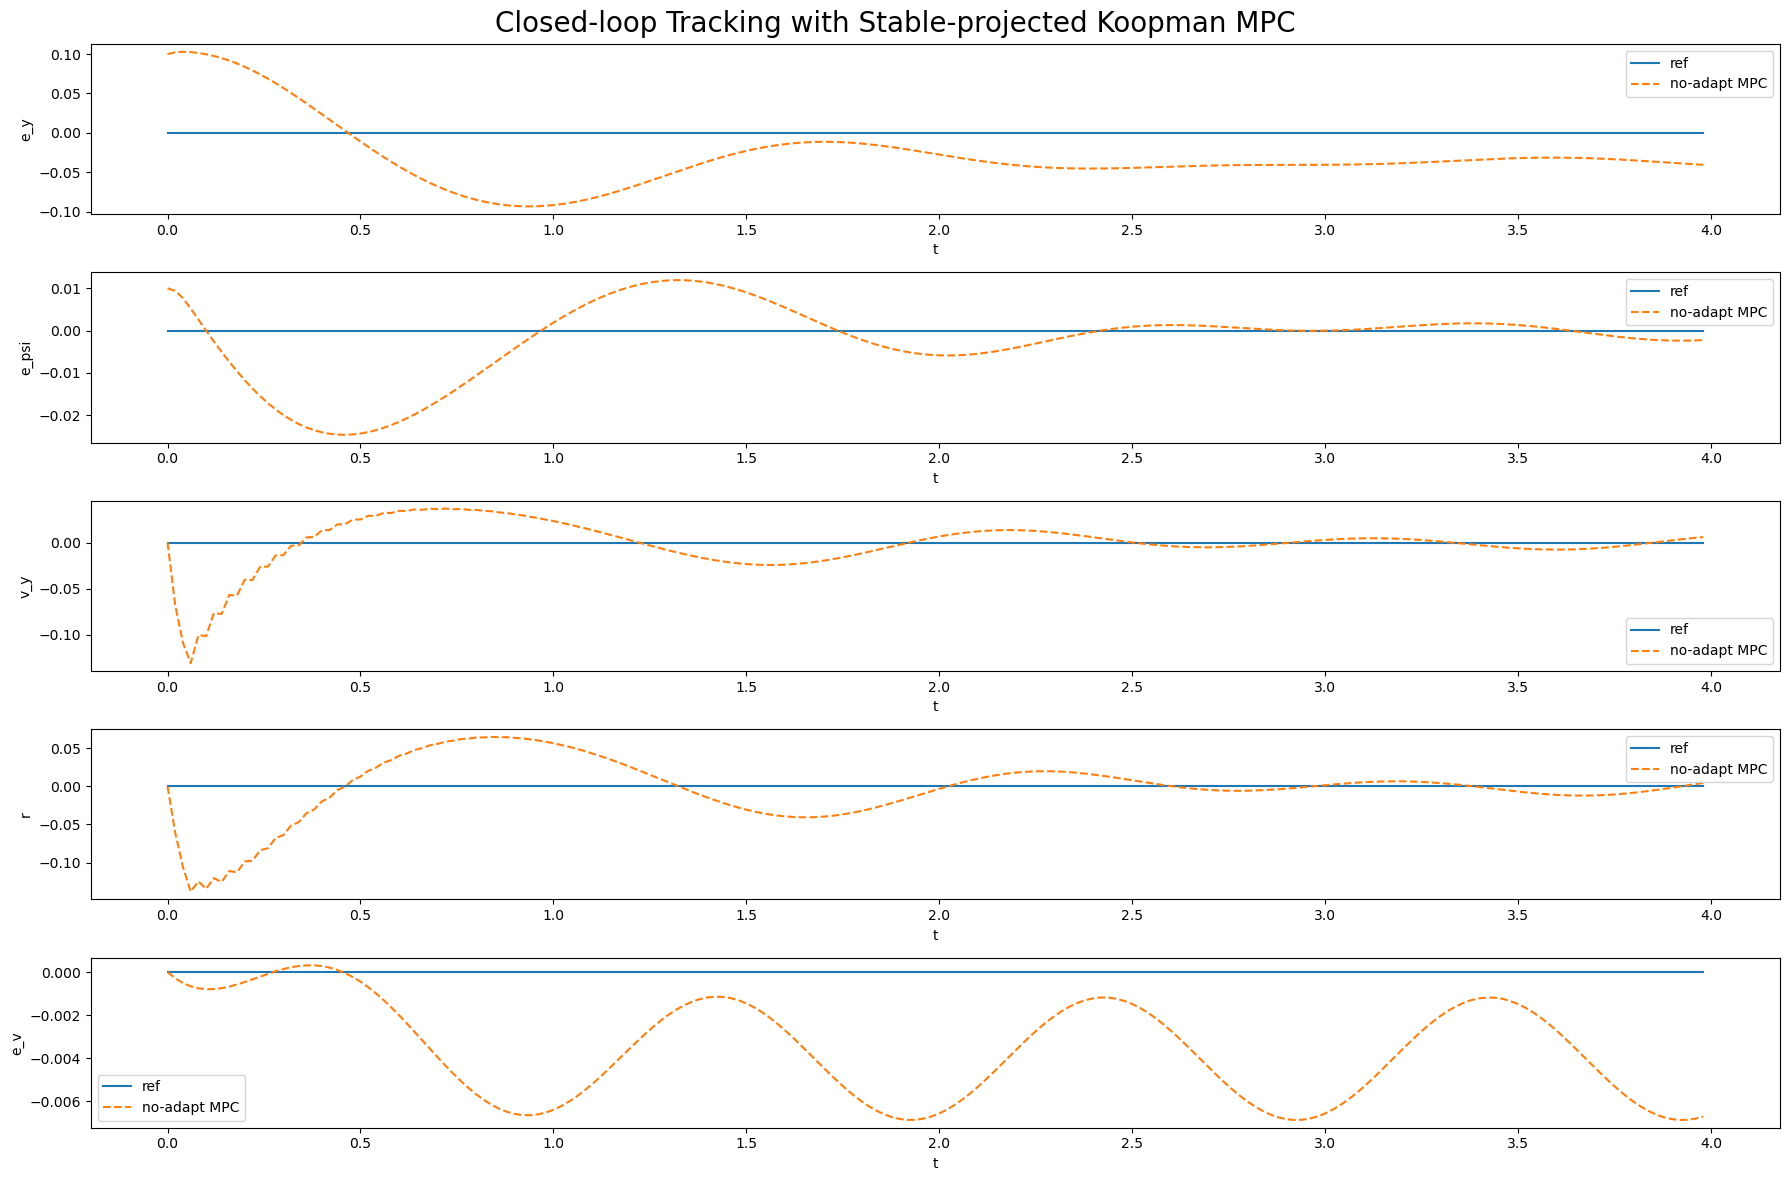

In [48]:
plt.figure(figsize=(18, 12))
for i in range(num_states):
    plt.subplot(num_states, 1, i + 1)
    plt.plot(t_ref, x_ref[i, :], label='ref')
    plt.plot(t_ref, xt_actual_lin_noadapt[:, i], '--', label='no-adapt MPC')
    plt.ylabel(state_labels[i])
    plt.xlabel("t")
    plt.legend()

plt.suptitle("Closed-loop Tracking with Stable-projected Koopman MPC", fontsize=20)
plt.tight_layout()
plt.show()

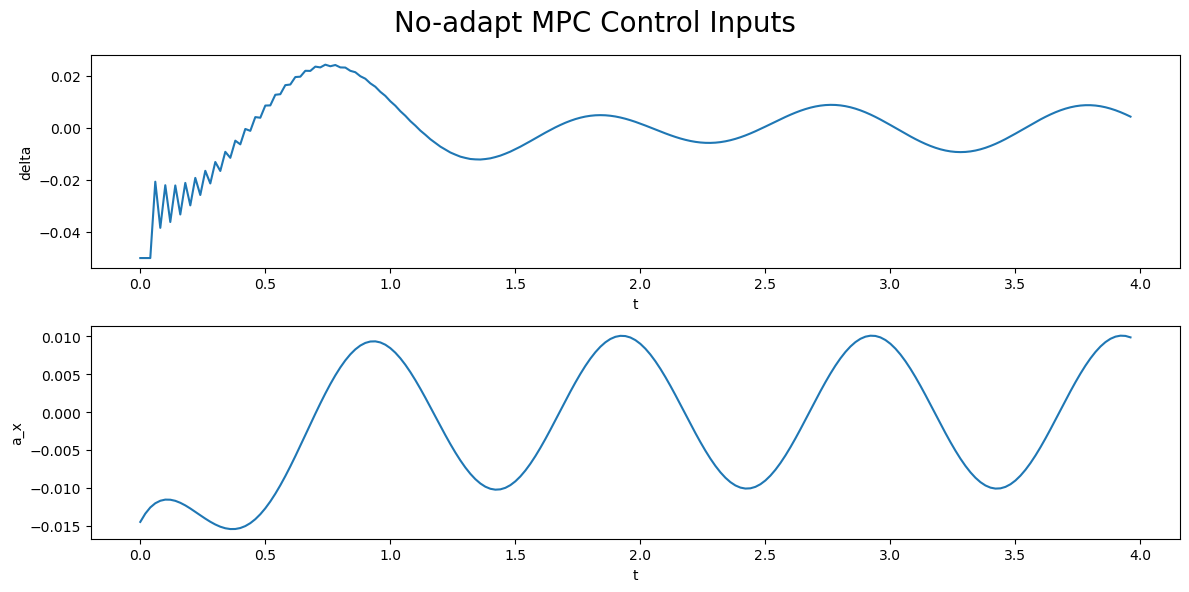

In [49]:
plt.figure(figsize=(12, 6))
for i in range(num_inputs):
    plt.subplot(num_inputs, 1, i + 1)
    plt.plot(t_ref[:-1], u_lin_noadapt[:, i])
    plt.ylabel(input_labels[i])
    plt.xlabel("t")

plt.suptitle("No-adapt MPC Control Inputs", fontsize=20)
plt.tight_layout()
plt.show()

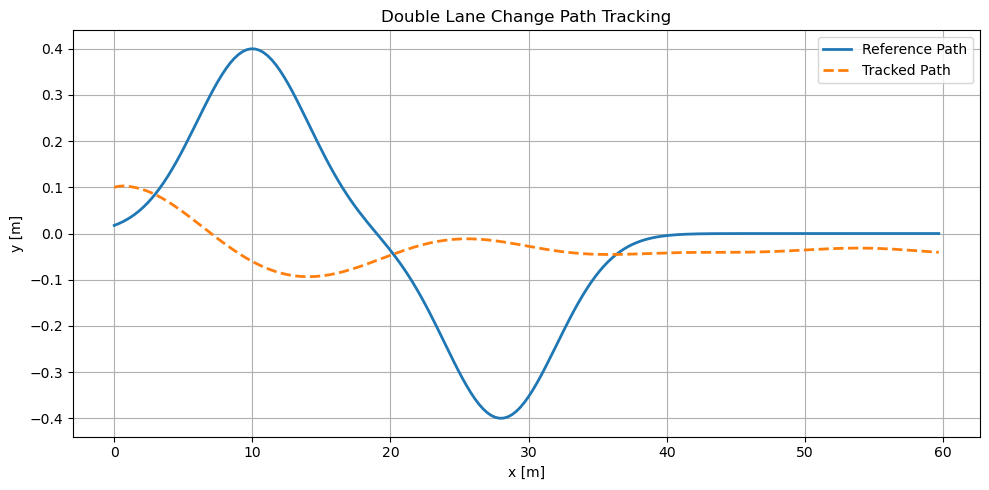

In [50]:
# ===== path tracking plot =====
x_actual_path = vx_nom * t_ref
y_actual_path = xt_actual_lin_noadapt[:, 0]   # 当前状态的 e_y 作为横向轨迹近似

plt.figure(figsize=(10, 5))
# plt.plot(x_path, label='Reference Path', linewidth=2)
plt.plot(x_path, y_ref_path, label='Reference Path', linewidth=2)
plt.plot(x_actual_path, y_actual_path, '--', label='Tracked Path', linewidth=2)
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title('Double Lane Change Path Tracking')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

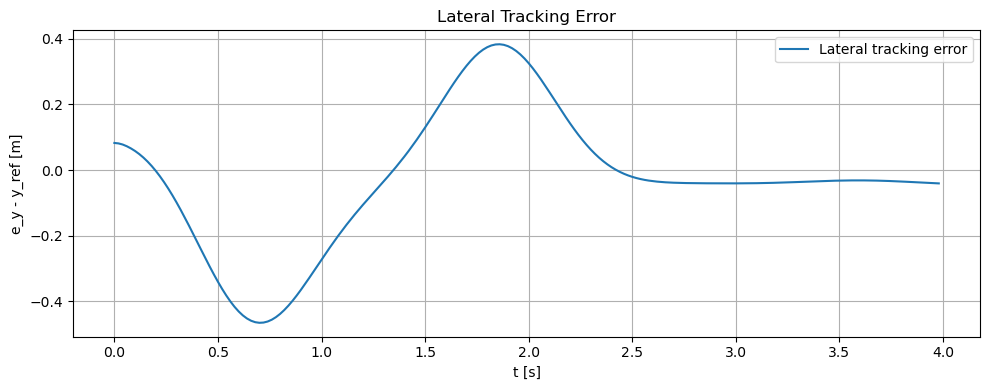

In [51]:
# ===== lateral tracking error =====
plt.figure(figsize=(10, 4))
plt.plot(t_ref, xt_actual_lin_noadapt[:, 0] - y_ref_path, label='Lateral tracking error')
plt.xlabel('t [s]')
plt.ylabel('e_y - y_ref [m]')
plt.title('Lateral Tracking Error')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [50]:
# """tracking without adaptation"""
# begin_linear_noadapt = time.time()
#
# def to_numpy(x):
#     if hasattr(x, 'detach'):
#         return x.detach().cpu().numpy()
#     return np.array(x)
#
# A_lin = to_numpy(model_koop_dnn_lin.A)
# B_lin = to_numpy(model_koop_dnn_lin.B)
# C_lin = to_numpy(model_koop_dnn_lin.C)
# # A_lin = np.array(model_koop_dnn_lin.A)
# # B_lin = np.array(model_koop_dnn_lin.B)
# # C_lin = np.array(model_koop_dnn_lin.C)
#
# solver_settings = {} #solver setting parameters for OSQP solver
# solver_settings['gen_embedded_ctrl'] = False
# solver_settings['warm_start'] = True
# solver_settings['polish'] = True
# solver_settings['polish_refine_iter'] = 6
# solver_settings['scaling'] = True
# solver_settings['adaptive_rho'] = True
# solver_settings['check_termination'] = 25
# solver_settings['max_iter'] = 1000
# solver_settings['eps_abs'] = 1e-6
# solver_settings['eps_rel'] = 1e-6
# solver_settings['eps_prim_inf'] = 1e-4
# solver_settings['eps_dual_inf'] = 1e-4
# # solver_settings['linsys_solver'] = 'qdldl'
#
# #controller that works on old model (unadapted)
# N_lin_noadapt = 15 #length of horizon
#
# x_ref_mpc = np.hstack((x_ref,np.tile(x_ref[:,-1].reshape(-1,1),N_lin_noadapt+1)))
#
# # Q_mpc_lin_noadapt = 10*scipy.sparse.diags(np.ones((num_states)))                     # State penalty matrix, trajectory generation
# # QN_mpc_lin_noadapt = 15*scipy.sparse.diags(np.ones((num_states)))         # Final state penalty matrix, trajectory generation
# # R_mpc_lin_noadapt = 10*scipy.sparse.eye(num_inputs)                       # Actuation penalty matrix, trajectory generation
# # R0_mpc_lin_noadapt = 10*scipy.sparse.csc_matrix(np.zeros(num_inputs))
# #
# # max_iter_lin = 1
# #
# # xmax_lin_noadapt = (phi_dot_ref*T_traj+50)*np.ones((num_states))                          # State constraints, trajectory generation
# # xmin_lin_noadapt = -xmax_lin_noadapt
# #
# # umax_lin_noadapt = 10*np.ones((num_inputs))
# # umin_lin_noadapt = -umax_lin_noadapt
#
# Q_mpc_lin_noadapt = 10 * scipy.sparse.diags([20, 20, 5, 5, 10])
# QN_mpc_lin_noadapt = 15 * scipy.sparse.diags([20, 20, 5, 5, 10])
# R_mpc_lin_noadapt = scipy.sparse.diags([5, 1])
# R0_mpc_lin_noadapt = scipy.sparse.csc_matrix(np.zeros(num_inputs))
#
# max_iter_lin = 1
#
# xmax_lin_noadapt = np.array([2.0, 0.5, 3.0, 1.0, 5.0])
# xmin_lin_noadapt = -xmax_lin_noadapt
#
# umax_lin_noadapt = np.array([0.08, 2.0])
# umin_lin_noadapt = np.array([-0.08, -3.0])
# """
# """
# # xt_lin_noadapt = np.zeros((traj_length+1, num_states))
# # xt_actual_lin_noadapt = np.zeros((traj_length, num_states))
# # xt_actual_lin_noadapt[0,:] = xt_lin_noadapt[0,:]
#
# xt_actual_lin_noadapt = np.zeros((traj_length, num_states))
# xt_actual_lin_noadapt[0, :] = np.zeros(num_states)
#
# x_init_lin_noadapt = np.linspace(xt_actual_lin_noadapt[0,:], xt_actual_lin_noadapt[0,:], N_lin_noadapt+1)
# u_init_lin_noadapt = 1*np.ones((num_inputs, N_lin_noadapt)).T
#
# n_lift = A_lin.shape[0]
# z_init_lin_noadapt = np.empty((N_lin_noadapt+1, n_lift))
# z0 = lift(xt_actual_lin_noadapt[0,:], model_koop_dnn_lin, net_params_lin)
# #lift initialized ststes
# for i in range(N_lin_noadapt+1):
#     z_init_lin_noadapt[i,:] = lift(x_init_lin_noadapt[i,:], model_koop_dnn_lin, net_params_lin)
#
# linear_model_no_adapt = linear_Dynamics(scipy.sparse.csc_matrix(A_lin),scipy.sparse.csc_matrix(B_lin), C_lin) #define a linear model
# controller_nmpc_lin_noadapt = NonlinearMPCController(linear_model_no_adapt, N_lin_noadapt, dt, umin_lin_noadapt, umax_lin_noadapt, xmin_lin_noadapt, xmax_lin_noadapt, Q_mpc_lin_noadapt, R_mpc_lin_noadapt, QN_mpc_lin_noadapt, solver_settings)
# controller_nmpc_lin_noadapt.construct_controller(z_init_lin_noadapt, u_init_lin_noadapt, x_ref[:,0])
#
# u_lin_noadapt = np.empty((num_inputs, traj_length-1)).T
# z_lin_noadapt = np.empty((n_obs_lin, traj_length)).T
#
# time_excess = 0
#
# for k in range(traj_length-1):
#
#     z_lin_noadapt[k,:] = lift(xt_actual_lin_noadapt[k,:], model_koop_dnn_lin, net_params_lin) #lifted state corresponding to current state
#
#     controller_nmpc_lin_noadapt.solve_to_convergence(x_ref_mpc[:,k+1:k+N_lin_noadapt+2], z_lin_noadapt[k,:], controller_nmpc_lin_noadapt.z_init, controller_nmpc_lin_noadapt.u_init, max_iter = max_iter_lin, eps = 1e-3)
#     controller_nmpc_lin_noadapt.update_initial_guess_()
#     u_lin_noadapt[k,:] = controller_nmpc_lin_noadapt.cur_u[0,:]
#
#     t1 = time.time()
#
#     if sensor_noise:
#         xt_actual_lin_noadapt[k+1,:] = FK_solver(xt_actual_lin_noadapt[k,:], u_lin_noadapt[k,:], sys_pars_new, sensor_noise, SNR_DB, k)
#     else:
#         xt_actual_lin_noadapt[k+1,:] = FK_solver(xt_actual_lin_noadapt[k,:], u_lin_noadapt[k,:], sys_pars_new, i=k)
#     t2 = time.time()
#     time_excess = (t2-t1) + time_excess
#
# end_linear_noadapt = time.time()
# time_linear_noadapt = (end_linear_noadapt - begin_linear_noadapt - time_excess)/traj_length

In [51]:
# k

In [52]:
# """Adaptation and control"""
#
# begin_linear_adapt = time.time()
# model_koop_dnn_lin = torch.load(file_koop_linear, weights_only=False)
#
# A_lin = np.array(model_koop_dnn_lin.A)
# B_lin = np.array(model_koop_dnn_lin.B)
# C_lin = np.array(model_koop_dnn_lin.C)
#
#
# adapt_window_ctrl_lin = 10 #hyperparameter
# forget_f = 0.75
#
# adapt_params_control_lin = {}
# adapt_params_control_lin['state_dim'] = num_states
# adapt_params_control_lin['ctrl_dim'] = num_inputs
# adapt_params_control_lin['lift_dim'] = net_params_lin["encoder_output_dim"]
# adapt_params_control_lin['optimizer'] = 'adam'
# adapt_params_control_lin['lr'] = 1e-5 # 5e-4
# adapt_params_control_lin['epochs'] = 10
# adapt_params_control_lin['batch_size'] = adapt_window_ctrl_lin
# adapt_params_control_lin['l2_reg'] = 5e-2
# adapt_params_control_lin['l1_reg'] = 5e-2
# adapt_params_control_lin['state_loss_coeff'] = 1
# adapt_params_control_lin['first_obs_const'] = net_params_lin["first_obs_const"]
# adapt_params_control_lin['override_C'] = net_params_lin["override_C"] # this makes the state a part of lifted state
# adapt_params_control_lin['warm_start'] = False
#
# del_A_ctrl_lin = np.zeros_like(A_lin)
# del_B_ctrl_lin = np.zeros_like(B_lin)
#
# linear_model_adapt = linear_Dynamics(scipy.sparse.csc_matrix(A_lin),scipy.sparse.csc_matrix(B_lin), C_lin)
#
# solver_settings = {}
# solver_settings['gen_embedded_ctrl'] = False
# solver_settings['warm_start'] = True
# solver_settings['polish'] = True
# solver_settings['polish_refine_iter'] = 10
# solver_settings['scaling'] = True
# solver_settings['adaptive_rho'] = False
# solver_settings['check_termination'] = 25
# solver_settings['max_iter'] = 1000
# solver_settings['eps_abs'] = 1e-7
# solver_settings['eps_rel'] = 1e-7
# solver_settings['eps_prim_inf'] = 1e-4
# solver_settings['eps_dual_inf'] = 1e-4
# # solver_settings['linsys_solver'] = 'qdldl'
#
# #Closed loop performance evaluation parameters:
# max_iter_lin = 1
# N_lin = N_lin_noadapt #length of horizon
# Q_mpc_lin = Q_mpc_lin_noadapt                       # State penalty matrix, trajectory generation
# QN_mpc_lin = QN_mpc_lin_noadapt         # Final state penalty matrix, trajectory generation
#
# R_mpc_lin = R_mpc_lin_noadapt                                    # Actuation penalty matrix, trajectory generation
# R0_mpc_lin = R0_mpc_lin_noadapt
#
# # Design trajectory:
# xt_lin = np.zeros((traj_length, num_states))
# xt_lin[0,:] = 0*x_ref[:,0]                   # Initial value, closed loop trajectory
#
# ymax_lin = xmax_lin_noadapt                        # State constraints, trajectory generation
# ymin_lin = xmin_lin_noadapt
# umax_lin = umax_lin_noadapt
# umin_lin = umin_lin_noadapt
#
# # Define initial solution for SQP algorithm:
# x_init_lin = np.linspace(xt_lin[0,:], xt_lin[0,:], N_lin+1)
# u_init_lin = 0.1*np.ones((num_inputs, N_lin)).T
#
# n_lift_lin = A_lin.shape[0]
# z_init_lin = np.empty((N_lin+1, n_lift_lin))
# z0_lin = lift(xt_lin[0,:], model_koop_dnn_lin, net_params_lin)
# for i in range(N_lin+1):
#     z_init_lin[i,:] = lift(x_init_lin[i,:], model_koop_dnn_lin, net_params_lin)
#
# # initialize state matricies
# u_ctrl_lin = np.zeros((traj_length-1, num_inputs))
# z_new_dyn_lin = np.zeros((n_obs_lin, traj_length)).T   #lifted state
# zt_old_dyn_lin = np.zeros((n_obs_lin, adapt_window_ctrl_lin)).T #actual lifted state
# del_Z_prime_ctrl_lin = np.zeros((n_obs_lin, adapt_window_ctrl_lin))
# x_new_dyn_lin = np.zeros((num_states, traj_length)).T #estimated values
# del_A_norm_ctrl_lin = np.zeros((traj_length,1))
# del_B_norm_ctrl_lin = np.zeros((traj_length,1))
#
# # initialize
# z_new_dyn_lin[0,:] = zt_old_dyn_lin[0,:] = z0_lin
# x_new_dyn_lin[0,:]  = xt_lin[0,:]
#
# #controller that works on adapting model
# controller_nmpc_adapt_lin = NonlinearMPCController(linear_model_adapt, N_lin, dt, umin_lin, umax_lin, ymin_lin, ymax_lin, Q_mpc_lin, R_mpc_lin, QN_mpc_lin, solver_settings)
# controller_nmpc_adapt_lin.construct_controller(z_init_lin, u_init_lin, x_ref[:,0])
#
# time_excess = 0
# for i in range(traj_length-1):
#     # incorrect dynamics
#     z_new_dyn_lin[i,:] = lift(x_new_dyn_lin[i,:], model_koop_dnn_lin, net_params_lin)
#
#     if i < adapt_window_ctrl_lin + 1 :
#         del_A_ctrl_lin = np.zeros_like(A_lin)
#         del_B_ctrl_lin = np.zeros_like(B_lin)
#     else:
#         for j in range(adapt_window_ctrl_lin):
#             zt_old_dyn_lin[j,:] = np.matmul(z_new_dyn_lin[i-adapt_window_ctrl_lin+j,:],linear_model_adapt.A.T.toarray())+np.matmul(u_ctrl_lin[i-adapt_window_ctrl_lin+j,:],linear_model_adapt.B.T.toarray())
#
#             del_Z_prime_ctrl_lin[:,j] = (forget_f**(adapt_window_ctrl_lin-j-1))*(z_new_dyn_lin[i-adapt_window_ctrl_lin+j+1,:]- zt_old_dyn_lin[j,:]).T
#
#         Z_obs_lin = z_new_dyn_lin[i-adapt_window_ctrl_lin:i,:].T
#         U_old_lin = u_ctrl_lin[i-adapt_window_ctrl_lin:i].T
#
#         #invoke neural net for adapation
#         adapt_network = AdaptNet_linear(adapt_params_control_lin)
#         adapt_network.model_pipeline(Z_obs_lin, U_old_lin, del_Z_prime_ctrl_lin, print_epoch = True)
#         del_A_ctrl_lin, del_B_ctrl_lin = adapt_network.get_del_matrices()
#
#     del_A_norm_ctrl_lin[i] = np.linalg.norm(del_A_ctrl_lin)
#     del_B_norm_ctrl_lin[i] = np.linalg.norm(del_B_ctrl_lin)
#
#     linear_model_adapt.A = scipy.sparse.csc_matrix(linear_model_adapt.A.toarray() + del_A_ctrl_lin)
#     linear_model_adapt.B = scipy.sparse.csc_matrix(linear_model_adapt.B.toarray() + del_B_ctrl_lin)
#
#     controller_nmpc_adapt_lin.solve_to_convergence(x_ref_mpc[:,i+1:N_lin+i+2], z_new_dyn_lin[i,:], controller_nmpc_adapt_lin.z_init, controller_nmpc_adapt_lin.u_init, max_iter = max_iter_lin, eps = 1e-8)
#     controller_nmpc_adapt_lin.update_initial_guess_()
#     u_ctrl_lin[i,:] = controller_nmpc_adapt_lin.cur_u[0,:]
#
#     t1 = time.time()
#
#     # adapted model
#
#     if sensor_noise:
#         x_new_dyn_lin[i+1,:] = FK_solver(x_new_dyn_lin[i,:], u_ctrl_lin[i,:], sys_pars_new, sensor_noise, SNR_DB, i)
#     else:
#         x_new_dyn_lin[i+1,:] = FK_solver(x_new_dyn_lin[i,:], u_ctrl_lin[i,:], sys_pars_new,i=i)
#
#
#     t2 = time.time()
#     time_excess = (t2-t1) + time_excess
#
# end_linear_adapt = time.time()
# time_linear_adapt = (end_linear_adapt - begin_linear_adapt - time_excess)/traj_length

In [53]:
# zt_old_dyn_lin[:,1::].shape

In [54]:
# # state estimation evolution
# plt.figure(figsize=(25,35))
# for i in range(int(num_states)):
#     plt.subplot(num_states,1,i+1)
#     plt.xlabel("t")
#     # plt.ylabel(leg[i])
#     plt.plot(t_ref, x_ref[i,:], label = 'ref')
#     plt.plot(t_ref, xt_actual_lin_noadapt[:,i],'--',label = "no adapt")
#     plt.plot(t_ref, x_new_dyn_lin[:,i],'-.', label = "adapt")
#     plt.legend()
# plt.suptitle("simultaneous adaptation and control", fontsize=30)
# plt.suptitle("Testing Performance", fontsize=30)
#
# # plt.savefig(img_pth+'/adapt_synchronization.pdf')
#
# plt.show()

In [55]:
# plt.plot(u_lin_noadapt[:,0], label = 'control noadapt')
# plt.plot(u_ctrl_lin[:,0], label = 'control adapt')
#
# plt.xlabel('iterations')
# plt.ylabel('u')

In [56]:
# fig, axs = plt.subplots(1,2,figsize=(15,5))
# axs[0].set_title(" ||del_A|| Evolution")
# axs[1].set_title("||del_B|| Evolution")
#
# axs[0].set(xlabel = 't', ylabel = '||del_A||')
# axs[1].set(xlabel = 't', ylabel = '||del_B||')
#
#
# axs[0].plot(del_A_norm_ctrl_lin)
#
# axs[1].plot(del_B_norm_ctrl_lin)
#
# plt.show()

In [57]:
# """ERROR PLOTS"""
# # plot dataset
# fig, axs = plt.subplots(num_states,1,figsize=(25,20))
# axs[0].set_title("Error x1")
# axs[1].set_title("Error x2")
#
# axs[0].set(xlabel = 't', ylabel = 'error x1')
# axs[1].set(xlabel = 't', ylabel = 'error x2')
#
#
# if linear:
#     error_adapt_lin = x_new_dyn_lin - x_ref.T
#     error_noadapt_lin = xt_actual_lin_noadapt - x_ref.T
#
#     for i in range(num_states):
#         axs[i].plot(error_noadapt_lin[:,i],":", label = 'error_linear_noadapt')
#         axs[i].plot(error_adapt_lin[:,i],"-.", label = 'error_linear_adapt')
#
# axs[0].legend()
# axs[1].legend()
#
#
# plt.show()

In [58]:
# from prettytable import PrettyTable

In [59]:
# import numpy as np

In [60]:
# error_adapt_lin_rel = np.divide(error_adapt_lin[1::,:], x_ref[:,1::].T)
# error_noadapt_lin_rel = np.divide(error_noadapt_lin[1::,:], x_ref[:,1::].T)

# rmse_noadapt = np.sqrt(np.mean(error_noadapt_lin**2, axis=0))
# rmse_adapt = np.sqrt(np.mean(error_adapt_lin**2, axis=0))
#
# print("RMSE no-adapt:")
# for i in range(num_states):
#     print(state_labels[i], rmse_noadapt[i])
#
# print("\nRMSE adapt:")
# for i in range(num_states):
#     print(state_labels[i], rmse_adapt[i])
#
# improve_ratio = (rmse_noadapt - rmse_adapt) / (rmse_noadapt + 1e-12)
#
# print("\nImprovement ratio:")
# for i in range(num_states):
#     print(state_labels[i], improve_ratio[i])



# rel_error_adapt_lin_norm = np.linalg.norm(error_adapt_lin_rel, axis = 0)/np.sqrt(t_ref[:-1].shape)
# rel_error_noadapt_lin_norm = np.linalg.norm(error_noadapt_lin_rel, axis = 0)/np.sqrt(t_ref[:-1].shape)
#
# error_adapt_lin_norm = np.linalg.norm(error_adapt_lin, axis = 0)/np.sqrt(t_ref.shape)
# error_noadapt_lin_norm = np.linalg.norm(error_noadapt_lin, axis = 0)/np.sqrt(t_ref.shape)

In [61]:
# # plot dataset
# fig, axs = plt.subplots(num_states,1,figsize=(25,20))
# axs[0].set_title("Error x1 norm")
# axs[1].set_title("Error x2 norm")
#
# axs[0].set(xlabel = 't', ylabel = 'error x1 norm')
# axs[1].set(xlabel = 't', ylabel = 'error x2 norm')
#
#
# if linear:
#     for i in range(num_states):
#         axs[i].plot(error_noadapt_lin_rel[:,i],":", label = 'error_linear_noadapt')
#         axs[i].plot(error_adapt_lin_rel[:,i],"-.", label = 'error_linear_adapt')
#
# axs[0].legend()
# axs[1].legend()
#
#
# plt.show()

In [62]:
# frac_imp = abs(error_adapt_lin_norm - error_noadapt_lin_norm)/error_noadapt_lin_norm
# frac_imp.shape

In [63]:
# """COMPUTE MEAN ERROR FOR ADAPTATION CASE"""
# mean_theta_no_adapt = np.sum(rel_error_noadapt_lin_norm[0::2])/N
# mean_theta_dot_no_adapt = np.sum(rel_error_noadapt_lin_norm[1::2])/N
#
# mean_theta_adapt = np.sum(rel_error_adapt_lin_norm[0::2])/N
# mean_theta_dot_adapt = np.sum(rel_error_adapt_lin_norm[1::2])/N
#
# mean_theta_frac = np.sum(frac_imp[0::2])/N
# mean_theta_dot_frac = np.sum(frac_imp[1::2])/N
#
# mean_frac_imp = np.sum(frac_imp)/2/N

In [64]:
# if linear:
#     data_table = PrettyTable(['Pendulum','theta (no adapt)', 'theta (adapt)','frac improvement (theta)', 'theta_dot (no adapt)', 'theta_dot (adapt)','frac improvement (theta_dot)'])
# for i in range(N):
#     data_table.add_row([str(i+1), str(rel_error_noadapt_lin_norm[2*i]), str(rel_error_adapt_lin_norm[2*i]),str(frac_imp[2*i]),str(rel_error_noadapt_lin_norm[2*i+1]), str(rel_error_adapt_lin_norm[2*i+1]),str(frac_imp[2*i+1]) ])
#
# data_table.add_row(['mean',str(mean_theta_no_adapt), str(mean_theta_adapt), str(mean_theta_frac), str(mean_theta_dot_no_adapt), str(mean_theta_dot_adapt), str(mean_theta_dot_frac)])
#
# data_table.add_row(['mean_frac_imp','-', '-','-','-','-',mean_frac_imp])

In [65]:
# frac_imp = abs(error_adapt_lin_norm - error_noadapt_lin_norm)/error_noadapt_lin_norm

In [66]:
# """COMPUTE MEAN ERROR FOR NO ADAPTATION CASE"""
# mean_theta_no_adapt = np.sum(rel_error_noadapt_lin_norm[0::2])/N
# mean_theta_dot_no_adapt = np.sum(rel_error_noadapt_lin_norm[1::2])/N
#
# mean_theta_adapt = np.sum(rel_error_adapt_lin_norm[0::2])/N
# mean_theta_dot_adapt = np.sum(rel_error_adapt_lin_norm[1::2])/N
#
# mean_theta_frac = np.sum(frac_imp[0::2])/N
# mean_theta_dot_frac = np.sum(frac_imp[1::2])/N
#
# mean_frac_imp = np.sum(frac_imp)/2/N

In [67]:
# if linear:
#     data_table = PrettyTable(['Pendulum','theta (no adapt)', 'theta (adapt)','frac improvement (theta)', 'theta_dot (no adapt)', 'theta_dot (adapt)','frac improvement (theta_dot)'])
# for i in range(N):
#     data_table.add_row([str(i+1), str(rel_error_noadapt_lin_norm[2*i]), str(rel_error_adapt_lin_norm[2*i]),str(frac_imp[2*i]),str(rel_error_noadapt_lin_norm[2*i+1]), str(rel_error_adapt_lin_norm[2*i+1]),str(frac_imp[2*i+1]) ])
#
# data_table.add_row(['mean',str(mean_theta_no_adapt), str(mean_theta_adapt), str(mean_theta_frac), str(mean_theta_dot_no_adapt), str(mean_theta_dot_adapt), str(mean_theta_dot_frac)])
#
# data_table.add_row(['mean_frac_imp','-', '-','-','-','-',mean_frac_imp])

In [68]:
# print(data_table)

In [69]:
# np.save("x_tra_conv",'x')